In [1]:
!pip install indic-nlp-library

In [2]:
# ======================
# IMPORTS & CONFIGURATION
# ======================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import pandas as pd
import re
import math
from collections import Counter, defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

# Configuration
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# HYPERPARAMETERS
MAX_SEQ_LEN = 35
BATCH_SIZE = 32      # Increased for faster training
EMBED_DIM = 64      # REDUCED from 512 (4x smaller!)
NUM_HEADS = 4        # Reduced from 8
NUM_ENCODER_LAYERS = 2  # Keep or reduce to 2
NUM_DECODER_LAYERS = 2  # Keep or reduce to 2
DROPOUT = 0.4        # Increased for regularization
LEARNING_RATE = 3e-4 # Slightly higher for faster convergence
NUM_EPOCHS = 30      # More epochs since smaller model
BEAM_SIZE = 3        # Smaller for faster inference

# Curriculum Learning
CURRICULUM_STAGES = [0.3, 0.6, 1.0]  # Progressive training
REVERSE_SOURCE = True  # Reverse input technique

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>" 
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


📥 Loading data...
✅ Loaded 68849 training pairs
✅ Loaded 19672 validation sources
Loaded 68849 English–Bengali sentence pairs
📊 English - Mean: 16.8, Max: 100, 95th %ile: 32.0
📊 Bengali - Mean: 14.3, Max: 84, 95th %ile: 27.0


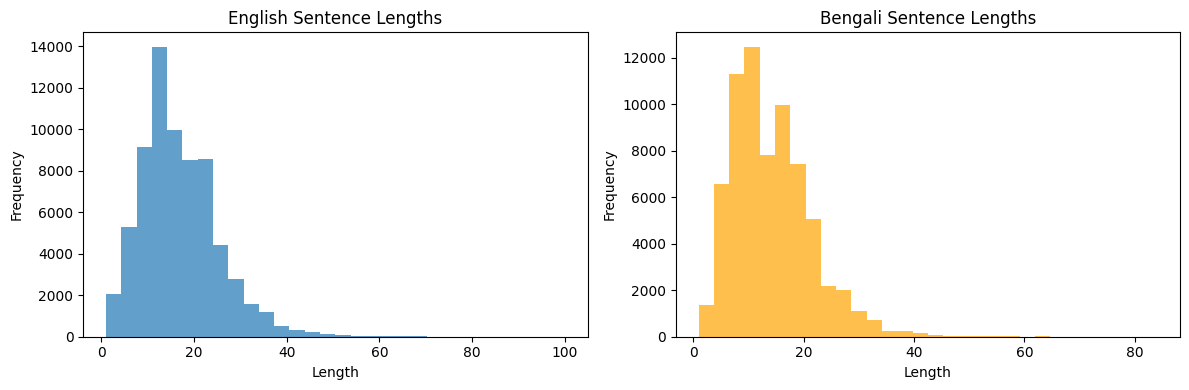

🎯 Recommended MAX_SEQ_LEN: 37


In [3]:
# ======================
# 📦 DATA LOADING & ANALYSIS
# ======================
import json
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# DATA LOADING
# -----------------------
TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH   = '/kaggle/input/nlp-capstoneproject/test_data1_final.json'

print("📥 Loading data...")

"""Load English-Bengali sentence pairs from train and validation JSONs."""
# --- Load train data ---
with open(TRAIN_PATH, 'r', encoding='utf-8') as f:
    data_train = json.load(f)

source_sentences_train, target_sentences_train, id_train = [], [], []
for language_pair, language_data in data_train.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                source = entry_data["source"]
                target = entry_data.get("target", "")
                if data_type == "Validation":
                    # skip, we’ll use the official val file
                    continue
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

# --- Load validation data ---
with open(VAL_PATH, 'r', encoding='utf-8') as f:
    data_val = json.load(f)

source_sentences_val, target_sentences_val, id_val = [], [], []
for language_pair, language_data in data_val.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                if data_type == "Test":
                    source_sentences_val.append(entry_data["source"])
                    id_val.append(entry_id)

print(f"✅ Loaded {len(source_sentences_train)} training pairs")
print(f"✅ Loaded {len(source_sentences_val)} validation sources")

# Combine for analysis (you can later split again)
en_sentences = source_sentences_train
bn_sentences = target_sentences_train

print(f"Loaded {len(en_sentences)} English–Bengali sentence pairs")

# -----------------------
# LENGTH ANALYSIS
# -----------------------
def analyze_sequence_lengths(en_sentences, bn_sentences):
    """Analyze sequence lengths to set optimal MAX_SEQ_LEN."""
    en_lengths = [len(sent.split()) for sent in en_sentences]
    bn_lengths = [len(sent.split()) for sent in bn_sentences]

    print(f"📊 English - Mean: {np.mean(en_lengths):.1f}, Max: {max(en_lengths)}, 95th %ile: {np.percentile(en_lengths, 95):.1f}")
    print(f"📊 Bengali - Mean: {np.mean(bn_lengths):.1f}, Max: {max(bn_lengths)}, 95th %ile: {np.percentile(bn_lengths, 95):.1f}")

    # Plot histograms
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(en_lengths, bins=30, alpha=0.7)
    plt.title('English Sentence Lengths')
    plt.xlabel('Length'); plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(bn_lengths, bins=30, alpha=0.7, color='orange')
    plt.title('Bengali Sentence Lengths')
    plt.xlabel('Length'); plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Recommend optimal MAX_SEQ_LEN
    recommended_len = max(np.percentile(en_lengths, 95), np.percentile(bn_lengths, 95))
    print(f"🎯 Recommended MAX_SEQ_LEN: {int(recommended_len + 5)}")


# -----------------------
# RUN
# -----------------------

analyze_sequence_lengths(en_sentences, bn_sentences)

In [4]:
# ======================
# PREPROCESSING & TOKENIZATION (FIXED)
# ======================
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from indicnlp.tokenize import indic_tokenize
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory

# Special tokens
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

# Create Bengali normalizer
factory = IndicNormalizerFactory()
bn_normalizer = factory.get_normalizer("bn")

# ======================
# PREPROCESSING FUNCTIONS
# ======================

def preprocess_english(text):
    """Light preprocessing for English"""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def preprocess_bengali(text):
    """Proper Bengali preprocessing using Indic NLP"""
    text = text.strip()

    # Normalize Bengali text using Indic NLP
    text = bn_normalizer.normalize(text)

    # Handle common Bengali punctuation
    text = re.sub(r'[৷]', '।', text)  # Convert Bengali period to purna viram
    text = re.sub(r'\s+', ' ', text)

    return text

# ======================
# TOKENIZATION
# ======================

def tokenize_bengali(text):
    """Proper Bengali tokenization using Indic NLP"""
    return indic_tokenize.trivial_tokenize(text)

def tokenize_english(text):
    """Simple English tokenization"""
    return text.split()

# ======================
# VOCABULARY CLASS
# ======================

class Vocabulary:
    def __init__(self, sentences, min_freq=2, lang='en'):
        self.min_freq = min_freq
        self.lang = lang
        self.build_vocab(sentences)

    def build_vocab(self, sentences):
        word_freq = Counter()
        for sentence in sentences:
            tokens = tokenize_bengali(sentence) if self.lang == 'bn' else tokenize_english(sentence)
            word_freq.update(tokens)

        self.itos = SPECIAL_TOKENS.copy()
        self.stoi = {token: i for i, token in enumerate(SPECIAL_TOKENS)}

        for word, freq in word_freq.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.itos.append(word)
                self.stoi[word] = len(self.itos) - 1

    def encode(self, text):
        tokens = tokenize_bengali(text) if self.lang == 'bn' else tokenize_english(text)
        return [self.stoi.get(token, self.stoi[UNK_TOKEN]) for token in tokens]

    def decode(self, indices):
        """Improved decode: keep <unk> visible, avoid removing all unknowns"""
        tokens = []
        for idx in indices:
            token = self.itos[idx]
            if token not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]:
                tokens.append(token)
        return ' '.join(tokens)

    def __len__(self):
        return len(self.itos)

# ======================
# MAIN EXECUTION (TEST)
# ======================

# ======================
# DATA LOADING & PREPROCESSING
# ======================

print("📥 Loading and preprocessing actual data...")

# Preprocess all your actual data
en_processed = [preprocess_english(sent) for sent in en_sentences]
bn_processed = [preprocess_bengali(sent) for sent in bn_sentences]

if REVERSE_SOURCE:
    print("🔄 Applying reverse input technique...")
    en_processed = [" ".join(reversed(sent.split())) for sent in en_processed]

# Split data properly - using your actual training data
train_size = int(0.9 * len(en_processed))
en_train = en_processed[:train_size]
en_val = en_processed[train_size:]
bn_train = bn_processed[:train_size]
bn_val = bn_processed[train_size:]

print(f"Training: {len(en_train)} pairs, Validation: {len(en_val)} pairs")

# ======================
# VOCABULARY BUILDING WITH ACTUAL DATA
# ======================
print("📚 Building vocabularies with actual data...")
src_vocab = Vocabulary(en_train + en_val, min_freq=1, lang='en')
tgt_vocab = Vocabulary(bn_train + bn_val, min_freq=1, lang='bn')

print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(tgt_vocab)}")
print(f"Source sample tokens: {src_vocab.itos[:15]}...")
print(f"Target sample tokens: {tgt_vocab.itos[:15]}...")

# ======================
# COMPREHENSIVE DECODING TEST
# ======================
print("\n" + "="*60)
print("🧪 COMPREHENSIVE DECODING TEST")
print("="*60)

def test_decoding_roundtrip(original_text, vocab, lang_name):
    """Test encoding and decoding roundtrip for a given text"""
    print(f"\n--- {lang_name} Test ---")
    print(f"Original: '{original_text}'")
    print(f"Length: {len(original_text)} chars")
    
    # Tokenize
    if lang_name == 'Bengali':
        tokens = tokenize_bengali(original_text)
    else:
        tokens = tokenize_english(original_text)
    print(f"Tokens: {tokens}")
    print(f"Token count: {len(tokens)}")
    
    # Encode
    encoded = vocab.encode(original_text)
    print(f"Encoded indices: {encoded}")
    
    # Decode
    decoded = vocab.decode(encoded)
    print(f"Decoded: '{decoded}'")
    print(f"Decoded length: {len(decoded)} chars")
    
    # Check match
    matches = original_text == decoded
    print(f"✅ Exact match: {matches}")
    
    if not matches:
        print("🔍 Character-by-character analysis:")
        min_len = min(len(original_text), len(decoded))
        for i in range(min_len):
            if original_text[i] != decoded[i]:
                print(f"   Position {i}: '{original_text[i]}' ≠ '{decoded[i]}'")
        if len(original_text) != len(decoded):
            print(f"   Length mismatch: original={len(original_text)}, decoded={len(decoded)}")
    
    return matches, tokens, encoded

# Test 1: Basic Bengali samples
print("\n📝 TEST 1: Basic Bengali Samples")
bengali_test_samples = [
    "ত্রিপুরা সরকারের তিনটি শাখা রয়েছে",
    "আমি বাংলায় গান গাই", 
    "বাংলাদেশের রাজধানী ঢাকা",
    "এটি একটি পরীক্ষা",
    "হ্যালো বিশ্ব"
]

bengali_matches = []
for sample in bengali_test_samples:
    matches, tokens, encoded = test_decoding_roundtrip(sample, tgt_vocab, "Bengali")
    bengali_matches.append(matches)

# Test 2: English samples
print("\n📝 TEST 2: English Samples")
english_test_samples = [
    "Tripura has three branches of government",
    "I sing in Bengali",
    "Dhaka is the capital of Bangladesh", 
    "This is a test",
    "Hello world"
]

english_matches = []
for sample in english_test_samples:
    matches, tokens, encoded = test_decoding_roundtrip(sample, src_vocab, "English")
    english_matches.append(matches)

# Test 3: Random samples from actual data with varying lengths
print("\n📝 TEST 3: Random Samples from Actual Data (Varying Lengths)")

def get_samples_by_length_range(data, min_len=2, max_len=50):
    """Get samples within specific character length range"""
    suitable_samples = []
    for sample in data:
        sample_clean = sample.strip()
        if min_len <= len(sample_clean) <= max_len:
            suitable_samples.append(sample_clean)
    return suitable_samples

# Get Bengali samples of different lengths
bn_short = get_samples_by_length_range(bn_processed, 2, 10)[:2]
bn_medium = get_samples_by_length_range(bn_processed, 11, 25)[:2] 
bn_long = get_samples_by_length_range(bn_processed, 26, 50)[:2]

test_bengali_actual = bn_short + bn_medium + bn_long
test_english_actual = [en_processed[bn_processed.index(bn)] for bn in test_bengali_actual]

print(f"\nTesting {len(test_bengali_actual)} actual Bengali samples:")
actual_bengali_matches = []
for i, sample in enumerate(test_bengali_actual):
    print(f"\n--- Actual Bengali Sample {i+1} ({len(sample)} chars) ---")
    matches, tokens, encoded = test_decoding_roundtrip(sample, tgt_vocab, f"Bengali Actual {i+1}")
    actual_bengali_matches.append(matches)
    print(f"Token count: {len(tokens)}")

print(f"\nTesting {len(test_english_actual)} actual English samples:")
actual_english_matches = []
for i, sample in enumerate(test_english_actual):
    print(f"\n--- Actual English Sample {i+1} ({len(sample)} chars) ---")
    matches, tokens, encoded = test_decoding_roundtrip(sample, src_vocab, f"English Actual {i+1}")
    actual_english_matches.append(matches)

# Test 4: Edge cases
print("\n📝 TEST 4: Edge Cases")

# Empty string
empty_encoded = tgt_vocab.encode("")
empty_decoded = tgt_vocab.decode(empty_encoded)
print(f"Empty string: encoded={tgt_vocab.encode('')}, decoded='{empty_decoded}'")

# Single character
single_char = "এ"
single_encoded = tgt_vocab.encode(single_char)
single_decoded = tgt_vocab.decode(single_encoded)
print(f"Single char '{single_char}': encoded={single_encoded}, decoded='{single_decoded}', match: {single_char == single_decoded}")

# Multiple spaces
spaces_text = "এটি  একটি   পরীক্ষা"
spaces_encoded = tgt_vocab.encode(spaces_text)
spaces_decoded = tgt_vocab.decode(spaces_encoded)
print(f"Multiple spaces: original='{spaces_text}', decoded='{spaces_decoded}', match: {spaces_text == spaces_decoded}")

# ======================
# SUMMARY STATISTICS
# ======================
print("\n" + "="*60)
print("📊 DECODING TEST SUMMARY")
print("="*60)

all_bengali_tests = bengali_matches + actual_bengali_matches
all_english_tests = english_matches + actual_english_matches

print(f"Bengali Tests: {sum(all_bengali_tests)}/{len(all_bengali_tests)} successful ({sum(all_bengali_tests)/len(all_bengali_tests)*100:.1f}%)")
print(f"English Tests: {sum(all_english_tests)}/{len(all_english_tests)} successful ({sum(all_english_tests)/len(all_english_tests)*100:.1f}%)")

# Vocabulary statistics
print(f"\n📈 Vocabulary Statistics:")
print(f"Source vocabulary size: {len(src_vocab)} tokens")
print(f"Target vocabulary size: {len(tgt_vocab)} tokens")

# Check for unknown tokens in test samples
print(f"\n🔍 Unknown Token Analysis:")
def check_unknown_tokens(text, vocab, lang_name):
    tokens = tokenize_bengali(text) if lang_name == 'Bengali' else tokenize_english(text)
    unknown_count = sum(1 for token in tokens if vocab.stoi.get(token, vocab.stoi[UNK_TOKEN]) == vocab.stoi[UNK_TOKEN])
    return unknown_count, len(tokens)

print("Basic Bengali samples unknown tokens:")
for sample in bengali_test_samples:
    unknown, total = check_unknown_tokens(sample, tgt_vocab, 'Bengali')
    print(f"  '{sample[:20]}...': {unknown}/{total} unknown tokens")

print("Basic English samples unknown tokens:")
for sample in english_test_samples:
    unknown, total = check_unknown_tokens(sample, src_vocab, 'English')
    print(f"  '{sample[:20]}...': {unknown}/{total} unknown tokens")

# ======================
# SAMPLE ENCODING/DECODING FOR MODEL INPUT
# ======================
print("\n" + "="*60)
print("🔧 Sample Encoding for Model Training")
print("="*60)

# Show how a training pair would be encoded
if len(en_train) > 0 and len(bn_train) > 0:
    sample_en = en_train[0]
    sample_bn = bn_train[0]
    
    print(f"Sample training pair:")
    print(f"English: '{sample_en}'")
    print(f"Bengali: '{sample_bn}'")
    
    # Encode with SOS and EOS for model training
    en_encoded = src_vocab.encode(sample_en)
    bn_encoded = tgt_vocab.encode(sample_bn)
    
    # For decoder input: add SOS token
    decoder_input = [tgt_vocab.stoi[SOS_TOKEN]] + bn_encoded
    # For decoder target: add EOS token  
    decoder_target = bn_encoded + [tgt_vocab.stoi[EOS_TOKEN]]
    
    print(f"Encoded English: {en_encoded}")
    print(f"Encoded Bengali: {bn_encoded}")
    print(f"Decoder input: {decoder_input}")
    print(f"Decoder target: {decoder_target}")
    
    # Decode back to verify
    decoded_en = src_vocab.decode(en_encoded)
    decoded_bn = tgt_vocab.decode(bn_encoded)
    print(f"Decoded English: '{decoded_en}'")
    print(f"Decoded Bengali: '{decoded_bn}'")
    print(f"English match: {sample_en == decoded_en}")
    print(f"Bengali match: {sample_bn == decoded_bn}")

print("\n✅ Vocabulary construction and testing completed!")

📥 Loading and preprocessing actual data...
🔄 Applying reverse input technique...
Training: 61964 pairs, Validation: 6885 pairs
📚 Building vocabularies with actual data...
Source vocab size: 90196
Target vocab size: 93500
Source sample tokens: ['<pad>', '<sos>', '<eos>', '<unk>', 'insouciance.', 'into', 'serenity', 'and', 'calmness', 'its', 'interchanges', 'rocks', 'marble', 'the', 'through']...
Target sample tokens: ['<pad>', '<sos>', '<eos>', '<unk>', 'এই', 'জায়গাগুলো', 'দেখতে', 'ভুলো', 'না', 'যেখানে', 'নর্মদা', 'নদী', 'মার্বেল', 'পাথরের', 'পাহাড়ের']...

🧪 COMPREHENSIVE DECODING TEST

📝 TEST 1: Basic Bengali Samples

--- Bengali Test ---
Original: 'ত্রিপুরা সরকারের তিনটি শাখা রয়েছে'
Length: 34 chars
Tokens: ['ত্রিপুরা', 'সরকারের', 'তিনটি', 'শাখা', 'রয়েছে']
Token count: 5
Encoded indices: [12898, 5203, 4023, 4486, 868]
Decoded: 'ত্রিপুরা সরকারের তিনটি শাখা রয়েছে'
Decoded length: 34 chars
✅ Exact match: True

--- Bengali Test ---
Original: 'আমি বাংলায় গান গাই'
Length: 19 chars
Tok

In [13]:
# ======================
# PROPER DATA SPLITTING FOR TRAIN/VALIDATION
# ======================

print("🔄 Properly splitting data for train/validation...")

# Use the full training data for both training and validation split
full_en_data = en_processed  # Your preprocessed English sentences
full_bn_data = bn_processed  # Your preprocessed Bengali sentences

print(f"Total available pairs: {len(full_en_data)}")

# Split into train and validation (90% train, 10% validation)
train_size = int(0.9 * len(full_en_data))
val_size = len(full_en_data) - train_size

# Create indices for splitting
indices = list(range(len(full_en_data)))
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create train/validation splits
en_train = [full_en_data[i] for i in train_indices]
bn_train = [full_bn_data[i] for i in train_indices]
en_val = [full_en_data[i] for i in val_indices]
bn_val = [full_bn_data[i] for i in val_indices]

print(f"✅ Training pairs: {len(en_train)}")
print(f"✅ Validation pairs: {len(en_val)}")

# Show some samples from validation set to confirm we have targets
print("\n📋 Validation set samples (with targets):")
for i in range(min(3, len(en_val))):
    print(f"  {i+1}. EN: '{en_val[i][:50]}...'")
    print(f"     BN: '{bn_val[i][:50]}...'")

# ======================
# DATASET & DATALOADER (UPDATED)
# ======================
class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len):
        self.src_sentences = src_sentences
        self.tgt_sentences = tgt_sentences
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.src_sentences)
    
    def __getitem__(self, idx):
        src_text = self.src_sentences[idx]
        tgt_text = self.tgt_sentences[idx]
        
        # Encode sequences
        src_encoded = [self.src_vocab.stoi[SOS_TOKEN]] + self.src_vocab.encode(src_text) + [self.src_vocab.stoi[EOS_TOKEN]]
        tgt_encoded = [self.tgt_vocab.stoi[SOS_TOKEN]] + self.tgt_vocab.encode(tgt_text) + [self.tgt_vocab.stoi[EOS_TOKEN]]
        
        # Truncate if necessary
        src_encoded = src_encoded[:self.max_len]
        tgt_encoded = tgt_encoded[:self.max_len]
        
        return torch.tensor(src_encoded), torch.tensor(tgt_encoded)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    
    # Pad sequences
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=src_vocab.stoi[PAD_TOKEN])
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_vocab.stoi[PAD_TOKEN])
    
    return src_padded, tgt_padded

# Create datasets
train_dataset = TranslationDataset(en_train, bn_train, src_vocab, tgt_vocab, MAX_SEQ_LEN)
val_dataset = TranslationDataset(en_val, bn_val, src_vocab, tgt_vocab, MAX_SEQ_LEN)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,num_workers=2,           # 🚀 Parallel data loading
    pin_memory=True,         # 🚀 Faster GPU transfer
    prefetch_factor=2,       # 🚀 Preload batches
                         )
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,num_workers=2,           # 🚀 Parallel data loading
    pin_memory=True,         # 🚀 Faster GPU transfer
    prefetch_factor=2,       # 🚀 Preload batches
                       )

print(f"✅ Datasets created - Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# ======================
# VERIFY DATALOADER OUTPUT
# ======================
print("\n🔍 Verifying dataloader output...")

# Get a batch from training loader
for src_batch, tgt_batch in train_loader:
    print(f"Source batch shape: {src_batch.shape}")  # [batch_size, seq_len]
    print(f"Target batch shape: {tgt_batch.shape}")  # [batch_size, seq_len]
    
    # Show first example in batch
    print(f"\nFirst example in batch:")
    src_seq = src_batch[0]
    tgt_seq = tgt_batch[0]
    
    # Remove padding for display
    src_non_pad = src_seq[src_seq != src_vocab.stoi[PAD_TOKEN]]
    tgt_non_pad = tgt_seq[tgt_seq != tgt_vocab.stoi[PAD_TOKEN]]
    
    print(f"Source tokens: {src_non_pad.tolist()}")
    print(f"Target tokens: {tgt_non_pad.tolist()}")
    
    # Decode back to text
    src_text = src_vocab.decode(src_non_pad.tolist())
    tgt_text = tgt_vocab.decode(tgt_non_pad.tolist())
    
    print(f"Source text: '{src_text}'")
    print(f"Target text: '{tgt_text}'")
    
    break  # Only show first batch

# ======================
# CHECK DATA STATISTICS
# ======================
print("\n📊 Data Statistics:")
def analyze_dataset(dataset, name):
    src_lengths = []
    tgt_lengths = []
    
    for src, tgt in dataset:
        src_non_pad = src[src != src_vocab.stoi[PAD_TOKEN]]
        tgt_non_pad = tgt[tgt != tgt_vocab.stoi[PAD_TOKEN]]
        src_lengths.append(len(src_non_pad))
        tgt_lengths.append(len(tgt_non_pad))
    
    print(f"{name}:")
    print(f"  Source - Avg: {np.mean(src_lengths):.1f}, Max: {max(src_lengths)}, 95%: {np.percentile(src_lengths, 95):.1f}")
    print(f"  Target - Avg: {np.mean(tgt_lengths):.1f}, Max: {max(tgt_lengths)}, 95%: {np.percentile(tgt_lengths, 95):.1f}")

analyze_dataset(train_dataset, "Training Set")
analyze_dataset(val_dataset, "Validation Set")

# ======================
# TEST BLEU SCORE COMPUTATION
# ======================
print("\n🧪 Testing BLEU score computation on validation set...")

def calculate_bleu(references, hypotheses):
    """Calculate BLEU score between references and hypotheses"""
    smoothie = SmoothingFunction().method4
    bleu_scores = []
    
    for ref, hyp in zip(references, hypotheses):
        # Tokenize for BLEU calculation
        ref_tokens = [tgt_vocab.encode(ref)]
        hyp_tokens = tgt_vocab.encode(hyp)
        
        # Calculate sentence BLEU
        score = sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoothie)
        bleu_scores.append(score)
    
    return np.mean(bleu_scores)

# Test with a few validation examples
test_references = bn_val[:5]
test_hypotheses = bn_val[:5]  # Using same as references for perfect score test

bleu_score = calculate_bleu(test_references, test_hypotheses)
print(f"BLEU score (perfect match test): {bleu_score:.4f}")

# Test with slightly modified hypotheses
if len(test_references) > 1:
    modified_hypotheses = test_references.copy()
    modified_hypotheses[0] = "এটি একটি পরীক্ষা"  # Change first one
    bleu_score_modified = calculate_bleu(test_references, modified_hypotheses)
    print(f"BLEU score (modified test): {bleu_score_modified:.4f}")

print("\n✅ Data preparation completed! Ready for model training.")

🔄 Properly splitting data for train/validation...
Total available pairs: 68849
✅ Training pairs: 61964
✅ Validation pairs: 6885

📋 Validation set samples (with targets):
  1. EN: '. hot is place affected The...'
     BN: 'আক্রান্ত অঙ্গও উষ্ণ হয়ে পড়ে ।...'
  2. EN: 'situations. abnormal to reactions normal are these...'
     BN: 'বেশিরভাগ ক্ষেত্রে অসময়োচিত ঘটনার সাথে এইগুলি হল স...'
  3. EN: '. fame the nor importance that either get not did ...'
     BN: 'উত্তরাখণ্ডে প্রচুর চিনার হওয়া সত্বেও এখানে চিনার ...'
✅ Datasets created - Train: 61964, Val: 6885

🔍 Verifying dataloader output...
Source batch shape: torch.Size([64, 35])
Target batch shape: torch.Size([64, 35])

First example in batch:
Source tokens: [1, 41725, 56, 14329, 339, 7165, 1452, 106, 41726, 13, 56, 13427, 526, 154, 7, 5756, 13, 56, 128, 10620, 177, 5683, 5194, 2]
Target tokens: [1, 3407, 4, 3251, 12603, 4093, 127, 3696, 177, 19, 32911, 554, 964, 1209, 116, 56, 3049, 161, 315, 1366, 1260, 3000, 168, 347, 14352, 9335, 

In [ ]:
# ======================
# ADD MISSING CONSTANTS FOR SEQ2SEQ
# ======================

# Add these constants that your seq2seq model expects
PAD_IDX = src_vocab.stoi[PAD_TOKEN]
TGT_SOS_IDX = tgt_vocab.stoi[SOS_TOKEN] 
TGT_EOS_IDX = tgt_vocab.stoi[EOS_TOKEN]
TGT_VOCAB_SIZE = len(tgt_vocab)
DEVICE = device
MAX_LEN = MAX_SEQ_LEN

print("🔧 Setting up constants for seq2seq...")
print(f"PAD_IDX: {PAD_IDX}")
print(f"TGT_SOS_IDX: {TGT_SOS_IDX}")
print(f"TGT_EOS_IDX: {TGT_EOS_IDX}")
print(f"TGT_VOCAB_SIZE: {TGT_VOCAB_SIZE}")

# ======================
# FIXED BAHdanauAttention FORWARD METHOD
# ======================
class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 512):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        # Fix shape issues
        dec_exp = self.W1(dec_hidden).unsqueeze(1)  # [B, 1, attn_dim]
        enc_feat = self.W2(enc_outputs)             # [B, T, attn_dim]
        
        # Use proper broadcasting
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)  # [B, T]
        
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
            
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

# ======================
# FIXED ENCODER FORWARD METHOD
# ======================
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths=None):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        # Fix: Handle different batch sizes and layers properly
        batch_size = h_n.size(1)
        hidden_size = h_n.size(2)
        
        # Get last layer forward/backward states
        forward_h = h_n[-2, :, :]   # [B, enc_hidden]
        backward_h = h_n[-1, :, :]  # [B, enc_hidden]
        dec_h = torch.cat([forward_h, backward_h], dim=1)  # [B, 2*enc_hidden]
        
        forward_c = c_n[-2, :, :]
        backward_c = c_n[-1, :, :]
        dec_c = torch.cat([forward_c, backward_c], dim=1)  # [B, 2*enc_hidden]
        
        return outputs, (dec_h, dec_c)

# ======================
# FIXED DECODER FORWARD_STEP METHOD
# ======================
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        # Fix: Ensure hidden/cell have correct dimensions
        output, (h_n, c_n) = self.lstm(
            lstm_input, 
            (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0))
        )
        
        output = output.squeeze(1)
        logits = self.fc_out(output)
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        
        return logits, next_hidden, next_cell, attn_w

# ======================
# FIXED SEQ2SEQ FORWARD METHOD
# ======================
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        if tgt is None:
            return self.greedy_decode(src)
            
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        
        max_len = tgt.size(1)
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE).to(DEVICE)
        
        input_token = tgt[:, 0]
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(
                input_token, hidden, cell, enc_outputs, enc_mask
            )
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1
            
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), TGT_SOS_IDX, dtype=torch.long, device=DEVICE)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(
                input_token, hidden, cell, enc_outputs, enc_mask
            )
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            # Stop if all sequences generated EOS
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# ======================
# SIMPLIFIED LOSS FUNCTION
# ======================
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int):
    """Simplified loss function"""
    if logits.dim() == 3:
        logits = logits[:, 1:].contiguous().view(-1, logits.size(-1))
        target = target[:, 1:].contiguous().view(-1)
    
    loss = nn.CrossEntropyLoss(ignore_index=pad_idx, reduction='mean')
    return loss(logits, target)

def translate_seq2seq(model, sentence, src_vocab, tgt_vocab, max_len=50):
    """Translation function for seq2seq model"""
    model.eval()
    
    # Preprocess
    if REVERSE_SOURCE:
        sentence = " ".join(reversed(sentence.split()))
    sentence = preprocess_english(sentence)
    
    # Encode
    tokens = [src_vocab.stoi[SOS_TOKEN]] + src_vocab.encode(sentence) + [src_vocab.stoi[EOS_TOKEN]]
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_tokens = model.greedy_decode(src_tensor, max_len=max_len)
    
    # Decode
    translation = tgt_vocab.decode(output_tokens.squeeze().tolist())
    return translation


# ======================
# QUICK CURRICULUM TRAINING - SIMPLIFIED
# ======================
def fast_curriculum_seq2seq():
    """Optimized curriculum training with BLEU scoring"""
    
    # Sort by length
    indices = list(range(len(train_dataset)))
    indices.sort(key=lambda i: len(train_dataset.src_sentences[i].split()))
    
    curriculum_stages = [
        (0.3, 5),   # Stage 1: 30% shortest, 5 epochs
        (0.6, 5),   # Stage 2: 60% shortest, 5 epochs  
        (1.0, 10)   # Stage 3: All data, 10 epochs
    ]
    
    best_bleu = 0.08
    total_epochs = 0
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
    
    for stage_idx, (frac, stage_epochs) in enumerate(curriculum_stages):
        print(f"\n🎯 STAGE {stage_idx+1}: {frac*100:.0f}% shortest sentences ({stage_epochs} epochs)")
        
        # Create stage dataset
        stage_indices = indices[:int(len(indices) * frac)]
        stage_dataset = Subset(train_dataset, stage_indices)
        stage_loader = DataLoader(stage_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)  # Fixed batch size
        
        for epoch in range(1, stage_epochs + 1):
            total_epochs += 1
            print(f"\n📚 Stage {stage_idx+1} Epoch {epoch}/{stage_epochs}")
            
            # Train one epoch
            model.train()
            epoch_loss = 0
            for src, tgt in tqdm(stage_loader, desc="Training"):
                src, tgt = src.to(device), tgt.to(device)
                optimizer.zero_grad()
                
                output = model(src, tgt, teacher_forcing_ratio=0.5)
                loss = masked_cross_entropy(output, tgt, PAD_IDX)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
            
            train_loss = epoch_loss / len(stage_loader)
            
            # Compute validation loss and BLEU
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for src, tgt in val_loader:
                    src, tgt = src.to(device), tgt.to(device)
                    output = model(src, tgt, teacher_forcing_ratio=0.0)  # No teacher forcing for validation
                    loss = masked_cross_entropy(output, tgt, PAD_IDX)
                    val_loss += loss.item()
            
            val_loss = val_loss / len(val_loader)
            
            # Quick BLEU check (25 samples for speed)
            val_bleu = compute_fast_bleu(model, val_loader, max_samples=25)
            
            # Show one validation example
            print(f"\n🔍 Validation Example:")
            idx = random.randint(0, len(val_dataset)-1)
            src_text = val_dataset.src_sentences[idx]
            tgt_text = val_dataset.tgt_sentences[idx]
            pred_text = translate_seq2seq(model, src_text, src_vocab, tgt_vocab)
            print(f"   SRC:  {src_text}")
            print(f"   TGT:  {tgt_text}")
            print(f"   PRED: {pred_text}")
            print(f"   MATCH: {'✅' if pred_text.strip() == tgt_text.strip() else '❌'}")
            
            print(f"\n📊 Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BLEU: {val_bleu:.4f}")
            
            # Update scheduler
            scheduler.step(val_bleu)
            
            # Save if BLEU improved
            if val_bleu > best_bleu:
                best_bleu = val_bleu
                torch.save({
                    'epoch': total_epochs,
                    'model_state': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'bleu': best_bleu,
                    'loss': val_loss
                }, f"seq2seq_bleu_{val_bleu:.4f}.pth")
                print(f"💾 NEW BEST BLEU: {val_bleu:.4f}")
            
            # Early exit if good enough
            if val_bleu > 0.12:  # Good target
                print("🎉 Target BLEU reached!")
                return best_bleu
    
    return best_bleu

def compute_fast_bleu(model, val_loader, max_samples=25):
    """Fast BLEU computation"""
    model.eval()
    smooth_fn = SmoothingFunction().method1
    total_bleu = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for batch_idx, (src_batch, tgt_batch) in enumerate(val_loader):
            if total_samples >= max_samples:
                break
                
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            
            for i in range(min(len(src_batch), max_samples - total_samples)):
                # Get reference
                ref_indices = tgt_batch[i].cpu().tolist()
                ref_tokens = [tgt_vocab.itos[idx] for idx in ref_indices 
                             if idx < len(tgt_vocab.itos) and tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]]
                
                # Get prediction
                pred_tokens = model.greedy_decode(src_batch[i:i+1]).squeeze()
                pred_tokens = [tgt_vocab.itos[idx] for idx in pred_tokens.tolist() 
                              if idx < len(tgt_vocab.itos) and tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]]
                
                if len(ref_tokens) > 0 and len(pred_tokens) > 0:
                    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth_fn)
                    total_bleu += bleu
                    total_samples += 1
    
    return total_bleu / max(total_samples, 1)

# ======================
# 🚀 RUN OPTIMIZED VERSION
# ======================
print("🔥 STARTING OPTIMIZED SEQ2SEQ WITH CURRICULUM...")

# Initialize model with smaller dimensions for speed
ENC_EMB_DIM = 128  # Reduced from 256
DEC_EMB_DIM = 128  # Reduced from 256  
ENC_HIDDEN = 128   # Reduced from 256
DEC_HIDDEN = 256   # Reduced from 512
ATTN_DIM = 128     # Reduced from 256

print(f"🔧 Using smaller model for faster training:")
print(f"   EMBED_DIM: {ENC_EMB_DIM}")
print(f"   HIDDEN_DIM: {ENC_HIDDEN}")

attention = BahdanauAttention(DEC_HIDDEN, ENC_HIDDEN * 2, ATTN_DIM)
encoder = Encoder(len(src_vocab), ENC_EMB_DIM, ENC_HIDDEN, dropout=0.3)
decoder = Decoder(len(tgt_vocab), DEC_EMB_DIM, DEC_HIDDEN, ENC_HIDDEN * 2, attention, dropout=0.3)
model = Seq2Seq(encoder, decoder).to(device)

print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Run training
final_bleu = fast_curriculum_seq2seq()
print(f"🎉 FINAL BLEU: {final_bleu:.4f}")

🔧 Setting up constants for seq2seq...
PAD_IDX: 0
TGT_SOS_IDX: 1
TGT_EOS_IDX: 2
TGT_VOCAB_SIZE: 93500
🔥 STARTING OPTIMIZED SEQ2SEQ WITH CURRICULUM...
🔧 Using smaller model for faster training:
   EMBED_DIM: 128
   HIDDEN_DIM: 128


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


📊 Model parameters: 48,529,852

🎯 STAGE 1: 30% shortest sentences (5 epochs)

📚 Stage 1 Epoch 1/5


Training: 100%|██████████| 291/291 [03:55<00:00,  1.24it/s]



🔍 Validation Example:
   SRC:  India. in applicable not is currency Nepal that note currency of re-exchanging for required are receipts bank the also daily; press the in announced are and Bank Rastra Nepal the by determined are currencies foreign the of exchange of rate The
   TGT:  বৈদেশিক মুদ্রার বিনিময় হার নির্ধারিত হয় নেপাল রাষ্ট্র ব্যঙ্কের দ্বারা এবং ঘোষিত হয় সংবাদমাধ্যমে প্রতিদিন এবং ব্যঙ্কের রসিদ প্রয়োজনীয় অর্থের পুনরায় বিনিময়ের জন্য দ্রষ্টব্য নেপালের অর্থ ভারতে গ্রহনযোগ্য নয়।
   PRED: এ ই   ,   ,   ,   ,   এ ব ং   এ ব ং   এ ব ং   ।   ।
   MATCH: ❌

📊 Train Loss: 7.5111 | Val Loss: 8.6520 | Val BLEU: 0.0007

📚 Stage 1 Epoch 2/5


...

Training: 100%|██████████| 291/291 [03:54<00:00,  1.24it/s]



🔍 Validation Example:
   SRC:  February. 3rd and January 27th between festival music classical annual an hosts also palace the and exhibits other among collection art priceless a is There
   TGT:  রয়েছে অমুল্য শিল্প সংগ্রহ অন্যান্য প্রদর্শনীর মধ্যে এবং প্রাসাদে একটি বাৎসরিক বাজনা সুরের উৎসব আয়োজন হয় ২৭ শে মে।
   PRED: ত ি ন ি   ,   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   এ ব ং   ।   ।   ।   ।
   MATCH: ❌

📊 Train Loss: 6.2657 | Val Loss: 8.4220 | Val BLEU: 0.0042

📚 Stage 1 Epoch 4/5


Training: 100%|██████████| 291/291 [03:57<00:00,  1.22it/s]



🔍 Validation Example:
   SRC:  representative. service customer rude the recording about think should you Alternately,
   TGT:  বিকল্পভাবে, অভদ্র গ্রাহক পরিষেবা প্রতিনিধির রেকর্ডিং করার কথা আপনার ভাবা উচিত।
   PRED: আ প ন ি   ,   ,   ,   ,   ,   ,   ,   ,   ক র ত ে   প া র ে   ।
   MATCH: ❌

📊 Train Loss: 5.9951 | Val Loss: 8.6317 | Val BLEU: 0.0016

📚 Stage 1 Epoch 5/5


Training:  94%|█████████▍| 273/291 [03:44<00:15,  1.17it/s]

## code

In [1]:
!pip install indic-nlp-library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.9 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import math
import random
import string
from collections import Counter, defaultdict
from typing import List, Tuple
from itertools import chain

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction, corpus_bleu
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Import Indic NLP for Bengali processing
try:
    from indicnlp.tokenize import indic_tokenize
    from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
    INDIC_NLP_AVAILABLE = True
except ImportError:
    print("⚠️ Indic NLP not available, using fallback Bengali processing")
    INDIC_NLP_AVAILABLE = False

# ======================
# Configuration
# ======================
TRAIN_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model parameters
MAX_LEN = 35
EMBED_DIM = 256
ENC_HIDDEN = 256
DEC_HIDDEN = 512
BATCH_SIZE = 64
N_EPOCHS = 70
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.5
VOCAB_SIZE = 8000

# Curriculum learning
USE_CURRICULUM = False  # Set to False to disable curriculum learning
CURRICULUM_STAGES = [(0.3, 20), (0.6, 20), (1.0, 40)]  # (data_fraction, epochs)

# Training monitoring
PATIENCE = 8
MIN_DELTA = 0.0001

SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ======================
# Bengali Preprocessing (from Code-2)
# ======================
class BengaliProcessor:
    def __init__(self):
        if INDIC_NLP_AVAILABLE:
            factory = IndicNormalizerFactory()
            self.normalizer = factory.get_normalizer("bn")
        else:
            self.normalizer = None
        
        # Bengali Unicode range and allowed characters
        self.bengali_range = r'\u0980-\u09FF'
        self.allowed_chars = set(string.digits + ' ')  # Numbers and space
        
    def preprocess(self, text: str) -> str:
        """Advanced Bengali preprocessing with non-Bengali character removal"""
        if not text:
            return ""
            
        # Normalize using Indic NLP if available
        if self.normalizer:
            text = self.normalizer.normalize(text)
        
        # Handle Bengali punctuation
        text = re.sub(r'[৷]', '।', text)
        
        # Remove non-Bengali characters (keep numbers and spaces)
        cleaned_chars = []
        for char in text:
            if (re.match(f'[{self.bengali_range}]', char) or 
                char in self.allowed_chars or
                char in ['।', '.', ',', '?', '!', '-']):  # Common punctuation
                cleaned_chars.append(char)
            else:
                # Replace non-Bengali characters with space
                cleaned_chars.append(' ')
        
        text = ''.join(cleaned_chars)
        
        # Clean up spaces
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
        
        return text

# ======================
# English Preprocessing (from Code-1)
# ======================
exclude = set(string.punctuation)
remove_digits = str.maketrans('', '', string.digits)

def preprocess_english(text: str) -> str:
    """Light English preprocessing"""
    text = text.lower()
    text = text.replace("'", "")
    text = ''.join(ch for ch in text if ch not in exclude)
    text = text.translate(remove_digits)
    text = text.strip()
    text = re.sub(" +", " ", text)
    return text

# ======================
# Subword Tokenizer (from Code-1)
# ======================
class SimpleSubwordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
        self.word_end = "</w>"  # Word boundary marker
        
    def train(self, sentences: List[str]):
        """Train subword vocabulary on sentences with word boundaries"""
        word_counts = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_counts.update(words)
            
        if not word_counts:
            self.vocab = {s:i for i,s in enumerate(self.specials)}
            self.inverse_vocab = {v:k for k,v in self.vocab.items()}
            return

        # Add word boundary to each word during training
        words_with_boundaries = {}
        for word, count in word_counts.items():
            words_with_boundaries[word + self.word_end] = count

        # Start with character vocabulary including word boundary
        chars = set()
        for w in words_with_boundaries:
            chars.update(list(w))

        word_symbols = {w: list(w) for w in words_with_boundaries}
        pairs = Counter()
        index_map = defaultdict(set)
        
        for w, cnt in words_with_boundaries.items():
            syms = word_symbols[w]
            for i in range(len(syms) - 1):
                p = (syms[i], syms[i+1])
                pairs[p] += cnt
                index_map[p].add(w)

        # Initial vocab including word boundary as a special token
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        
        # Add word boundary to vocabulary
        if self.word_end not in self.vocab:
            self.vocab[self.word_end] = idx
            idx += 1
            
        for ch in sorted(chars):
            if ch not in self.vocab and ch != self.word_end:  # Don't add word_end again
                self.vocab[ch] = idx
                idx += 1

        max_new_tokens = max(0, self.vocab_size - idx)
        max_merges = min(max_new_tokens, 2000)
        merges = []

        pbar = tqdm(range(max_merges), desc="BPE merges", unit="merge")
        for merge_i in pbar:
            if not pairs:
                break

            best_pair, best_count = pairs.most_common(1)[0]
            if best_count <= 0:
                break

            merges.append(best_pair)
            affected_words = list(index_map.get(best_pair, []))
            
            if not affected_words:
                del pairs[best_pair]
                continue

            for w in affected_words:
                cnt = words_with_boundaries[w]
                syms = word_symbols[w]
                old_pairs = [(syms[i], syms[i+1]) for i in range(len(syms)-1)]

                for p in old_pairs:
                    pairs[p] -= cnt
                    if pairs[p] <= 0:
                        try:
                            del pairs[p]
                        except KeyError:
                            pass
                    index_map[p].discard(w)

                new_syms = []
                i = 0
                a, b = best_pair
                while i < len(syms):
                    if i < len(syms) - 1 and syms[i] == a and syms[i+1] == b:
                        new_syms.append(a + b)
                        i += 2
                    else:
                        new_syms.append(syms[i])
                        i += 1
                word_symbols[w] = new_syms

                for i in range(len(new_syms) - 1):
                    p = (new_syms[i], new_syms[i+1])
                    pairs[p] += cnt
                    index_map[p].add(w)

        pbar.close()

        # Build final vocab
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        
        # Add word boundary
        self.vocab[self.word_end] = idx
        idx += 1

        final_chars = set()
        for syms in word_symbols.values():
            for s in syms:
                if len(s) == 1 and s != self.word_end:
                    final_chars.add(s)
        for ch in sorted(final_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        seen = set(self.vocab.keys())
        for pair in merges:
            merged = ''.join(pair)
            if merged not in seen and idx < self.vocab_size:
                self.vocab[merged] = idx
                idx += 1
                seen.add(merged)
            if idx >= self.vocab_size:
                break

        self.inverse_vocab = {v:k for k,v in self.vocab.items()}

    def encode(self, text: str) -> List[int]:
        """Encode text to subword indices with word boundaries"""
        words = text.split()
        tokens = []
        if len(self.vocab) == 0:
            return [self.vocab.get("<UNK>", 1)]
            
        max_sub_len = max((len(k) for k in self.vocab.keys() if k not in self.specials and k != self.word_end), default=1)
        
        for word in words:
            # Add word boundary marker
            word_with_boundary = word + self.word_end
            i = 0
            L = len(word_with_boundary)
            
            while i < L:
                matched = False
                for length in range(min(max_sub_len, L - i), 0, -1):
                    subword = word_with_boundary[i:i+length]
                    idx = self.vocab.get(subword)
                    if idx is not None:
                        tokens.append(idx)
                        i += length
                        matched = True
                        break
                if not matched:
                    tokens.append(self.vocab.get("<UNK>", 1))
                    i += 1
        return tokens
    
    def decode(self, indices: List[int]) -> str:
        """Decode indices back to text using word boundaries"""
        tokens = []
        current_word = []
    
        for idx in indices:
            token = self.inverse_vocab.get(idx, "<UNK>")
    
            if token in self.specials:
                continue
    
            # If token contains the boundary marker inside (e.g., 'the</w>')
            if self.word_end in token:
                parts = token.split(self.word_end)
                for i, part in enumerate(parts):
                    if part:
                        current_word.append(part)
                    # Every time we hit the boundary, close the word
                    if i < len(parts) - 1:
                        if current_word:
                            tokens.append(''.join(current_word))
                            current_word = []
            else:
                current_word.append(token)
    
        # Handle last word
        if current_word:
            tokens.append(''.join(current_word))
    
        return ' '.join(tokens)
    
    def __len__(self):
        return len(self.vocab)

# ======================
# Data Loading & Processing
# ======================
def load_and_validate_data(json_path: str, max_len: int = MAX_LEN):
    """Load data with validation to ensure Bengali targets"""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    srcs, tgts = [], []
    lang_data = data.get("English-Bengali", {})
    
    bengali_processor = BengaliProcessor()
    
    print("🔍 Validating data language integrity...")
    bengali_samples = 0
    english_samples = 0
    
    for dtype, entries in lang_data.items():
        for eid, entry in entries.items():
            src_text = entry.get("source", "").strip()
            tgt_text = entry.get("target", "").strip()
            
            if not src_text or not tgt_text:
                continue
            
            # Detect language of target
            bengali_chars = re.findall(r'[\u0980-\u09FF]', tgt_text)
            english_chars = re.findall(r'[a-zA-Z]', tgt_text)
            
            # Target should be Bengali (primarily Bengali characters)
            if len(bengali_chars) > len(english_chars):
                bengali_samples += 1
                # Process texts
                src_processed = preprocess_english(src_text)
                tgt_processed = bengali_processor.preprocess(tgt_text)
                
                if len(src_processed.split()) <= max_len and len(tgt_processed.split()) <= max_len:
                    srcs.append(src_processed)
                    tgts.append(tgt_processed)
            else:
                english_samples += 1
    
    print(f"✅ Bengali targets: {bengali_samples}, ❌ English targets: {english_samples}")
    print(f"📊 Final dataset: {len(srcs)} valid pairs")
    
    return srcs, tgts

# ======================
# Dataset & DataLoader
# ======================
def pad_sequence_post(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

def collate_fn(batch):
    srcs = [torch.tensor(x["src"], dtype=torch.long) for x in batch]
    tgts = [torch.tensor(x["tgt"], dtype=torch.long) for x in batch]
    srcs = [s[:MAX_LEN] for s in srcs]
    tgts = [t[:MAX_LEN] for t in tgts]
    srcs_p = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgts_p = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return srcs_p, tgts_p

class TranslationDataset(Dataset):
    def __init__(self, src_texts: List[str], tgt_texts: List[str], 
                 src_tokenizer: SimpleSubwordTokenizer, tgt_tokenizer: SimpleSubwordTokenizer):
        assert len(src_texts) == len(tgt_texts)
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer
        
        # Precompute lengths (without padding)
        self.src_lengths = []
        self.tgt_lengths = []
        for src, tgt in zip(src_texts, tgt_texts):
            src_ids = src_tokenizer.encode(src)
            tgt_ids = tgt_tokenizer.encode(tgt)
            self.src_lengths.append(len(src_ids))
            self.tgt_lengths.append(len(tgt_ids))

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        s = self.src_texts[idx]
        t = self.tgt_texts[idx]
        
        src_ids = self.src_tokenizer.encode(s)
        tgt_ids = [self.tgt_tokenizer.vocab["<SOS>"]] + self.tgt_tokenizer.encode(t) + [self.tgt_tokenizer.vocab["<EOS>"]]
        
        src_ids = pad_sequence_post(src_ids, MAX_LEN, PAD_IDX)
        tgt_ids = pad_sequence_post(tgt_ids, MAX_LEN, PAD_IDX)
        return {"src": src_ids, "tgt": tgt_ids}
    
    def get_original_length(self, idx):
        """Get original length (without padding) for curriculum learning"""
        return max(self.src_lengths[idx], self.tgt_lengths[idx])

# ======================
# Model Architecture (from Code-1 with fixes)
# ======================
class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 256):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        dec_exp = self.W1(dec_hidden).unsqueeze(1)
        enc_feat = self.W2(enc_outputs)
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        forward_h = h_n[-2,:,:]
        backward_h = h_n[-1,:,:]
        dec_h = torch.cat([forward_h, backward_h], dim=1)
        
        forward_c = c_n[-2,:,:]
        backward_c = c_n[-1,:,:]
        dec_c = torch.cat([forward_c, backward_c], dim=1)
        
        return outputs, (dec_h, dec_c)

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        output, (h_n, c_n) = self.lstm(lstm_input, (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0)))
        output = output.squeeze(1)
        logits = self.fc_out(output)
        
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        return logits, next_hidden, next_cell, attn_w

class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        
        max_len = tgt.size(1) if tgt is not None else MAX_LEN
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE).to(DEVICE)
        
        input_token = tgt[:, 0]
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            if teacher_force and tgt is not None:
                input_token = tgt[:, t]
            else:
                input_token = top1
                
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), fill_value=TGT_SOS_IDX, dtype=torch.long, device=src.device)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# ======================
# Loss & Evaluation
# ======================
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int):
    if logits.dim() == 3:
        B, T, V = logits.size()
        logits = logits[:, 1:, :].contiguous()
        target = target[:, 1:].contiguous()
        logits = logits.view(-1, V)
        target = target.view(-1)
    
    loss = nn.CrossEntropyLoss(reduction="none", ignore_index=pad_idx)
    per_token = loss(logits, target)
    mask = (target != pad_idx).float()
    per_token = per_token * mask
    
    if mask.sum() == 0:
        return per_token.mean()
    return per_token.sum() / mask.sum()

def compute_comprehensive_bleu(model: Seq2Seq, data_loader: DataLoader, tgt_tokenizer: SimpleSubwordTokenizer, 
                             max_batches=20, max_length=None):
    """Compute BLEU-1 to BLEU-4 with length filtering for curriculum learning"""
    model.eval()
    references = []
    hypotheses = []
    
    with torch.no_grad():
        batch_count = 0
        for src_batch, tgt_batch in data_loader:
            if batch_count >= max_batches:
                break
                
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            preds = model.greedy_decode(src_batch, max_len=tgt_batch.size(1))
            
            for ref_ids, pred_ids in zip(tgt_batch.cpu().tolist(), preds.cpu().tolist()):
                # Filter by length if specified (for curriculum validation)
                if max_length is not None:
                    ref_non_pad = [ix for ix in ref_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)]
                    if len(ref_non_pad) > max_length:
                        continue
                
                ref_text = tgt_tokenizer.decode([ix for ix in ref_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                pred_text = tgt_tokenizer.decode([ix for ix in pred_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                
                ref_words = ref_text.split()
                pred_words = pred_text.split()
                
                if ref_words and pred_words:
                    references.append([ref_words])
                    hypotheses.append(pred_words)
            
            batch_count += 1
    
    model.train()
    
    if not references:
        return 0.0, 0.0, 0.0, 0.0
    
    try:
        bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
        bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
        
        return bleu1, bleu2, bleu3, bleu4
    except:
        return 0.0, 0.0, 0.0, 0.0

def show_translation_examples(model: Seq2Seq, dataset: TranslationDataset, src_tokenizer: SimpleSubwordTokenizer, 
                            tgt_tokenizer: SimpleSubwordTokenizer, num_examples=1, max_length=None):
    """Show translation examples with length filtering"""
    model.eval()
    examples_shown = 0
    
    with torch.no_grad():
        while examples_shown < num_examples:
            idx = random.randint(0, len(dataset) - 1)
            
            # Check length if specified
            if max_length is not None and dataset.get_original_length(idx) > max_length:
                continue
                
            item = dataset[idx]
            src_tensor = torch.tensor(item["src"]).unsqueeze(0).to(DEVICE)
            tgt_tensor = torch.tensor(item["tgt"]).unsqueeze(0).to(DEVICE)
            
            pred_tensor = model.greedy_decode(src_tensor)
            
            src_text = dataset.src_texts[idx]
            tgt_text = dataset.tgt_texts[idx]
            pred_text = tgt_tokenizer.decode([ix for ix in pred_tensor.squeeze().tolist() 
                                            if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
            
            print(f"\n📝 Example {examples_shown + 1}:")
            print(f"   SRC: {src_text}")
            print(f"   TGT: {tgt_text}")
            print(f"   PRED: {pred_text}")
            print(f"   MATCH: {'✅' if pred_text.strip() == tgt_text.strip() else '❌'}")
            
            examples_shown += 1
    
    model.train()

# ======================
# Curriculum Learning
# ======================
def get_curriculum_subsets(dataset: TranslationDataset, stages):
    """Create curriculum learning subsets based on sentence length"""
    # Sort indices by length
    indices = list(range(len(dataset)))
    indices.sort(key=lambda i: dataset.get_original_length(i))
    
    subsets = []
    for frac, epochs in stages:
        end_idx = int(len(indices) * frac)
        stage_indices = indices[:end_idx]
        subsets.append((Subset(dataset, stage_indices), epochs, frac))
    
    return subsets

# ======================
# Main Training Function
# ======================

print("🚀 Starting Hybrid Bengali-English Translation Training")
print(f"📊 Curriculum Learning: {'ENABLED' if USE_CURRICULUM else 'DISABLED'}")

# Load and preprocess data
print("\n📥 Loading and preprocessing data...")
src_all, tgt_all = load_and_validate_data(TRAIN_JSON, MAX_LEN)

# Split data
n = len(src_all)
train_end = int(0.95 * n)
val_end = int(0.98 * n)

train_src = src_all[:train_end]
train_tgt = tgt_all[:train_end]
val_src = src_all[train_end:val_end]
val_tgt = tgt_all[train_end:val_end]
test_src = src_all[val_end:]
test_tgt = tgt_all[val_end:]

print(f"📊 Data split -> Train: {len(train_src)}, Val: {len(val_src)}, Test: {len(test_src)}")

# Train tokenizers
print("\n🔤 Training subword tokenizers...")
src_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)
tgt_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)

src_tokenizer.train(train_src)
tgt_tokenizer.train(train_tgt)

print(f"📚 Vocab sizes -> Source: {len(src_tokenizer)}, Target: {len(tgt_tokenizer)}")
    
# ======================
# TOKENIZER VALIDATION CHECK
# ======================
print("\n🧪 TOKENIZER VALIDATION CHECK")
print("=" * 60)

def test_tokenizer_roundtrip(text, tokenizer, language):
    """Test encode-decode roundtrip for a given text"""
    print(f"\n🔍 Testing {language} tokenizer:")
    print(f"   Original: '{text}'")
    
    # Encode
    encoded = tokenizer.encode(text)
    print(f"   Encoded: {encoded}")
    print(f"   Length: {len(encoded)} tokens")
    
    # Decode
    decoded = tokenizer.decode(encoded)
    print(f"   Decoded: '{decoded}'")
    
    # Check if roundtrip preserves meaning
    matches = text.strip() == decoded.strip()
    print(f"   Roundtrip match: {'✅' if matches else '❌'}")
    
    if not matches:
        print(f"   Original words: {text.split()}")
        print(f"   Decoded words: {decoded.split()}")
    
    return matches

# Test samples for English (Source)
print("\n📝 ENGLISH (SOURCE) SAMPLES:")
print("-" * 40)

english_test_samples = [
    "hello world",  # Simple
    "the quick brown fox jumps over the lazy dog",  # Medium length
    "neural machine translation is amazing",  # Technical terms
    "what time is it now",  # Question
    "this is a very long sentence with many words to test tokenization capabilities"  # Long
]

# Add some actual samples from training data
english_actual_samples = random.sample(train_src, 3)
english_test_samples.extend(english_actual_samples)

eng_success_count = 0
for sample in english_test_samples:
    if test_tokenizer_roundtrip(sample, src_tokenizer, "English"):
        eng_success_count += 1

# Test samples for Bengali (Target)
print("\n📝 BENGALI (TARGET) SAMPLES:")
print("-" * 40)

bengali_test_samples = [
    "হ্যালো বিশ্ব",  # Simple
    "আমি বাংলায় কথা বলি",  # Basic sentence
    "মানুষের মুখে মুখে রূপান্তরিত হয়",  # Medium complexity
    "কেমন আছেন আপনি",  # Question
    "এটি একটি খুব দীর্ঘ বাক্য অনেক শব্দ দিয়ে টোকেনাইজেশন পরীক্ষা করার জন্য"  # Long
]

# Add some actual samples from training data
bengali_actual_samples = random.sample(train_tgt, 3)
bengali_test_samples.extend(bengali_actual_samples)

# Add some challenging Bengali samples with special characters/numbers
challenging_bengali = [
    "আমার ১০টি বই আছে",  # With numbers
    "তিনি ডাক্তার, না ইঞ্জিনিয়ার?",  # With punctuation
    "বাংলাদেশের রাজধানী ঢাকা",  # Proper nouns
]
bengali_test_samples.extend(challenging_bengali)

bn_success_count = 0
for sample in bengali_test_samples:
    if test_tokenizer_roundtrip(sample, tgt_tokenizer, "Bengali"):
        bn_success_count += 1

# Test OOV (Out-of-Vocabulary) handling
print("\n🚨 OOV (OUT-OF-VOCABULARY) TESTING:")
print("-" * 40)

# Test with made-up or rare words
oov_english = [
    "supercalifragilisticexpialidocious",  # Very long word
    "xyzabc123",  # Random characters
    "quantumcomputingai"  # Compound technical term
]

print("🔍 Testing English OOV handling:")
for oov_word in oov_english:
    encoded = src_tokenizer.encode(oov_word)
    decoded = src_tokenizer.decode(encoded)
    print(f"   OOV: '{oov_word}' → Encoded: {encoded} → Decoded: '{decoded}'")

# Test vocabulary coverage
print("\n📊 VOCABULARY COVERAGE ANALYSIS:")
print("-" * 40)

def analyze_vocab_coverage(texts, tokenizer, language):
    """Analyze vocabulary coverage for a set of texts"""
    total_tokens = 0
    unk_count = 0
    unique_tokens = set()
    
    unk_idx = tokenizer.vocab.get("<UNK>", 1)
    
    for text in texts[:1000]:  # Sample first 1000 texts for speed
        encoded = tokenizer.encode(text)
        total_tokens += len(encoded)
        unk_count += encoded.count(unk_idx)
        unique_tokens.update(encoded)
    
    coverage = ((total_tokens - unk_count) / total_tokens * 100) if total_tokens > 0 else 0
    print(f"   {language} Coverage: {coverage:.2f}% ({total_tokens - unk_count}/{total_tokens} tokens)")
    print(f"   Unique tokens used: {len(unique_tokens)}")
    return coverage

eng_coverage = analyze_vocab_coverage(train_src, src_tokenizer, "English")
bn_coverage = analyze_vocab_coverage(train_tgt, tgt_tokenizer, "Bengali")

# Test special tokens
print("\n🎯 SPECIAL TOKENS TEST:")
print("-" * 40)

special_tokens_test = "<SOS> hello world <EOS>"
print(f"   Special tokens text: '{special_tokens_test}'")
encoded_special = src_tokenizer.encode(special_tokens_test)
decoded_special = src_tokenizer.decode(encoded_special)
print(f"   Encoded: {encoded_special}")
print(f"   Decoded: '{decoded_special}'")

# Summary
print("\n" + "=" * 60)
print("📋 TOKENIZER VALIDATION SUMMARY")
print("=" * 60)
print(f"✅ English roundtrip success: {eng_success_count}/{len(english_test_samples)}")
print(f"✅ Bengali roundtrip success: {bn_success_count}/{len(bengali_test_samples)}")
print(f"📈 English vocabulary coverage: {eng_coverage:.2f}%")
print(f"📈 Bengali vocabulary coverage: {bn_coverage:.2f}%")

# Check if we should proceed
min_coverage = 85.0  # Minimum acceptable coverage
if eng_coverage < min_coverage or bn_coverage < min_coverage:
    print(f"\n⚠️ WARNING: Low vocabulary coverage (< {min_coverage}%)")
    print("   Consider increasing VOCAB_SIZE or checking data quality")

if eng_success_count < len(english_test_samples) * 0.7 or bn_success_count < len(bengali_test_samples) * 0.7:
    print(f"\n❌ CRITICAL: Poor roundtrip performance")
    print("   Tokenizer may have issues. Check implementation.")
    # You might want to pause here for debugging
    # import sys
    # sys.exit(1)
else:
    print(f"\n🎉 Tokenizers validated successfully! Proceeding with training...")


🚀 Starting Hybrid Bengali-English Translation Training
📊 Curriculum Learning: DISABLED

📥 Loading and preprocessing data...
🔍 Validating data language integrity...
✅ Bengali targets: 68802, ❌ English targets: 47
📊 Final dataset: 67177 valid pairs
📊 Data split -> Train: 63818, Val: 2015, Test: 1344

🔤 Training subword tokenizers...


BPE merges: 100%|██████████| 2000/2000 [00:15<00:00, 125.58merge/s]


📚 Vocab sizes -> Source: 2150, Target: 2089

🧪 TOKENIZER VALIDATION CHECK

📝 ENGLISH (SOURCE) SAMPLES:
----------------------------------------

🔍 Testing English tokenizer:
   Original: 'hello world'
   Encoded: [653, 614, 4, 650]
   Length: 4 tokens
   Decoded: 'hello world'
   Roundtrip match: ✅

🔍 Testing English tokenizer:
   Original: 'the quick brown fox jumps over the lazy dog'
   Encoded: [160, 311, 1473, 4, 1114, 27, 270, 10, 19, 679, 945, 787, 154, 713, 160, 454, 30, 163, 479, 175]
   Length: 20 tokens
   Decoded: 'the quick brown fox jumps over the lazy dog'
   Roundtrip match: ✅

🔍 Testing English tokenizer:
   Original: 'neural machine translation is amazing'
   Encoded: [269, 1001, 1954, 395, 1550, 821, 13, 183, 177, 211, 1557, 180]
   Length: 12 tokens
   Decoded: 'neural machine translation is amazing'
   Roundtrip match: ✅

🔍 Testing English tokenizer:
   Original: 'what time is it now'
   Encoded: [497, 436, 177, 240, 696]
   Length: 5 tokens
   Decoded: 'what time i

In [3]:
# Set global variables
global PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX, TGT_VOCAB_SIZE
PAD_IDX = src_tokenizer.vocab["<PAD>"]
TGT_SOS_IDX = tgt_tokenizer.vocab["<SOS>"]
TGT_EOS_IDX = tgt_tokenizer.vocab["<EOS>"]
TGT_VOCAB_SIZE = len(tgt_tokenizer)

# Create datasets
train_dataset = TranslationDataset(train_src, train_tgt, src_tokenizer, tgt_tokenizer)
val_dataset = TranslationDataset(val_src, val_tgt, src_tokenizer, tgt_tokenizer)
test_dataset = TranslationDataset(test_src, test_tgt, src_tokenizer, tgt_tokenizer)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
# Build model
print("\n🏗️ Building model...")
enc = Encoder(len(src_tokenizer), EMBED_DIM, ENC_HIDDEN).to(DEVICE)
attention = BahdanauAttention(dec_hidden_dim=DEC_HIDDEN, enc_hidden_dim=ENC_HIDDEN*2, attn_dim=256).to(DEVICE)
dec = Decoder(len(tgt_tokenizer), EMBED_DIM, DEC_HIDDEN, ENC_HIDDEN*2, attention).to(DEVICE)
model = Seq2Seq(enc, dec).to(DEVICE)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, verbose=True)

# Training tracking
# Training tracking - REMOVE THESE GLOBAL VARIABLES
# best_bleu = 0.0
# best_loss = float('inf')
# no_improve_epochs = 0
total_epochs = 0

# Curriculum learning setup
if USE_CURRICULUM:
    curriculum_subsets = get_curriculum_subsets(train_dataset, CURRICULUM_STAGES)
else:
    # Regular training with full dataset
    curriculum_subsets = [(train_dataset, N_EPOCHS, 1.0)]

print("\n🎯 Starting training...")

for stage_idx, (stage_dataset, stage_epochs, data_frac) in enumerate(curriculum_subsets):
    stage_loader = DataLoader(stage_dataset, batch_size=BATCH_SIZE, shuffle=not USE_CURRICULUM, collate_fn=collate_fn)
    
    print(f"\n📚 Stage {stage_idx + 1}: {data_frac*100:.0f}% data ({stage_epochs} epochs)")
    if USE_CURRICULUM:
        max_stage_length = max(stage_dataset.dataset.get_original_length(i) for i in stage_dataset.indices)
        print(f"   Max sequence length in stage: {max_stage_length}")
    
    # STAGE-SPECIFIC TRACKING - ADD THIS
    stage_best_bleu = 0.0
    stage_best_loss = float('inf')
    stage_no_improve_epochs = 0
    
    for epoch in range(1, stage_epochs + 1):
        total_epochs += 1
        
        # Training
        model.train()
        epoch_loss = 0.0
        current_tf_ratio = max(0.3, TEACHER_FORCING_RATIO * (0.95 ** (total_epochs // 5)))
        
        pbar = tqdm(stage_loader, desc=f"Epoch {total_epochs} [Train]", leave=False)
        for src_batch, tgt_batch in pbar:
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=current_tf_ratio)
            loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            #pbar.set_postfix({"loss": f"{loss.item():.4f}", "tf": f"{current_tf_ratio:.2f}"})
        
        avg_train_loss = epoch_loss / len(stage_loader)
        
        # Validation
        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for src_batch, tgt_batch in val_loader:
                src_batch = src_batch.to(DEVICE)
                tgt_batch = tgt_batch.to(DEVICE)
                outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=0.0)
                loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
                val_loss_total += loss.item()
        
        avg_val_loss = val_loss_total / len(val_loader)
        
        # BLEU calculation with length filtering for curriculum
        max_val_length = max_stage_length if USE_CURRICULUM else None
        bleu1, bleu2, bleu3, bleu4 = compute_comprehensive_bleu(
            model, val_loader, tgt_tokenizer, max_batches=10, max_length=max_val_length
        )
        current_bleu = bleu4
        
        # Update scheduler - USE STAGE BLEU FOR SCHEDULING
        scheduler.step(current_bleu)
        
        # Print epoch results
        print(f"\n📊 Epoch {total_epochs} Summary:")
        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"   BLEU Scores -> 1: {bleu1:.4f}, 2: {bleu2:.4f}, 3: {bleu3:.4f}, 4: {bleu4:.4f}")
        
        # Show translation examples
        show_translation_examples(model, val_dataset, src_tokenizer, tgt_tokenizer, 
                                num_examples=1, max_length=max_val_length)
        
        # Check for improvement - USE STAGE-SPECIFIC TRACKING
        improved = False
        if current_bleu > stage_best_bleu + MIN_DELTA:
            stage_best_bleu = current_bleu
            improved = True
            print(f"🎉 Stage {stage_idx + 1} BLEU improved to: {stage_best_bleu:.4f}")
        
        if avg_val_loss < stage_best_loss - MIN_DELTA:
            stage_best_loss = avg_val_loss
            improved = True
            print(f"🎉 Stage {stage_idx + 1} Loss improved to: {stage_best_loss:.4f}")
        
        # Save model and handle early stopping - USE STAGE-SPECIFIC
        if improved:
            stage_no_improve_epochs = 0
            
            # Save checkpoint
            ckpt_path = os.path.join(SAVE_DIR, f"best_model_bn_stage{stage_idx+1}.pth")
            torch.save({
                "epoch": total_epochs,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "src_tokenizer": src_tokenizer,
                "tgt_tokenizer": tgt_tokenizer,
                "bleu": stage_best_bleu,
                "loss": stage_best_loss,
                "stage": stage_idx + 1
            }, ckpt_path)
            print(f"💾 Saved stage {stage_idx + 1} checkpoint: {ckpt_path}")
        else:
            stage_no_improve_epochs += 1
            print(f"⚠️ No improvement in stage {stage_idx + 1} ({stage_no_improve_epochs}/{PATIENCE})")
        
        # Early stopping - USE STAGE-SPECIFIC
        if stage_no_improve_epochs >= PATIENCE:
            print(f"🛑 Early stopping triggered for stage {stage_idx + 1}.")
            break
    
    # Print stage summary
    print(f"\n🎯 Stage {stage_idx + 1} completed:")
    print(f"   Best BLEU: {stage_best_bleu:.4f}")
    print(f"   Best Loss: {stage_best_loss:.4f}")


# Final evaluation
print("\n🏁 Training complete! Final evaluation...")
final_bleu1, final_bleu2, final_bleu3, final_bleu4 = compute_comprehensive_bleu(
    model, test_loader, tgt_tokenizer, max_batches=250
)
print(f"🎯 Final Test BLEU Scores:")
print(f"   BLEU-1: {final_bleu1:.4f}")
print(f"   BLEU-2: {final_bleu2:.4f}") 
print(f"   BLEU-3: {final_bleu3:.4f}")
print(f"   BLEU-4: {final_bleu4:.4f}")



🏗️ Building model...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



🎯 Starting training...

📚 Stage 1: 100% data (70 epochs)



📊 Epoch 1 Summary:
   Train Loss: 6.2946 | Val Loss: 6.5398
   BLEU Scores -> 1: 0.0841, 2: 0.0268, 3: 0.0102, 4: 0.0033

📝 Example 1:
   SRC: what is the stock price of hdfc
   TGT: এর স্টকের দাম কত
   PRED: ঢাকা লাখ কি
   MATCH: ❌
🎉 Stage 1 BLEU improved to: 0.0033
🎉 Stage 1 Loss improved to: 6.5398
💾 Saved stage 1 checkpoint: ./checkpoints/best_model_bn_stage1.pth



📊 Epoch 2 Summary:
   Train Loss: 5.6677 | Val Loss: 6.4823
   BLEU Scores -> 1: 0.0967, 2: 0.0366, 3: 0.0137, 4: 0.0040

📝 Example 1:
   SRC: these days we hear less about infectious diseases like tuberculosis tb or cholera
   TGT: এখন যক্ষা বা কলেরার মত ছোঁয়াচে রোগ সম্বন্ধে কম শুনতে পাই।
   PRED: এই সপ্তাহে আমরা আমরা আমরা আমরা , , , , , , , , , , , বা বা বা বা বা বা বা ।
   MATCH: ❌
🎉 Stage 1 BLEU improved to: 0.0040
🎉 Stage 1 Loss improved to: 6.4823
💾 Saved stage 1 checkpoint: ./checkpoints/best_model_bn_stage1.pth


...


📊 Epoch 24 Summary:
   Train Loss: 4.4384 | Val Loss: 6.0874
   BLEU Scores -> 1: 0.1978, 2: 0.0990, 3: 0.0541, 4: 0.0287

📝 Example 1:
   SRC: post regularly so others can see what you’re doing and that you’re actively taking clients
   TGT: নিয়মিত পোস্ট করুন যাতে অন্যরা দেখতে পায় যে আপনি কী করছেন এবং আপনি সক্রিয়ভাবে গ্রাহক গ্রহণ করছেন।
   PRED: যতক্ষণ করুন, যাতে আপনি অন্যান্য করতে সাহায্য করতে পারে, এবং আপনি আপনি আপনি ক্লাব করতে পারেন।
   MATCH: ❌
🎉 Stage 1 BLEU improved to: 0.0287
🎉 Stage 1 Loss improved to: 6.0874
💾 Saved stage 1 checkpoint: ./checkpoints/best_model_bn_stage1.pth



📊 Epoch 25 Summary:
   Train Loss: 4.4405 | Val Loss: 6.0738
   BLEU Scores -> 1: 0.2001, 2: 0.1003, 3: 0.0539, 4: 0.0278

📝 Example 1:
   SRC: below this store youll see a swipeable list of all listed images on the shop in graphical form only
   TGT: এই সংগ্রহের নীচে, এই দোকানটিতে থাকা তালিকাভুক্ত সমস্ত পণ্যের একটি সোয়াইপযোগ্য তালিকা শুধুমাত্র চিত্র রূপে দেখতে পাবেন।
   PRED: এই দোকানটি আপনি দোকান দেখিই আপনি দেখবে যে সমস্ত তালিকাতালিকাতালিকাভুক্ত তালিকাতালিতালিকাভুক্ত তালিকাভুক্ত করুন।
   MATCH: ❌
🎉 Stage 1 Loss improved to: 6.0738
💾 Saved stage 1 checkpoint: ./checkpoints/best_model_bn_stage1.pth



📊 Epoch 26 Summary:
   Train Loss: 4.4458 | Val Loss: 6.0570
   BLEU Scores -> 1: 0.2001, 2: 0.1012, 3: 0.0553, 4: 0.0300

📝 Example 1:
   SRC: many words in the khasi language have been borrowed from indoaryan languages such as assamese bengali and nepali
   TGT: খাসি ভাষার অনেক শব্দ ইন্দো-আর্য ভাষাসমূহ যেমন অসমীয়া, বাংলা এবং নেপালি থেকে ধার করা হয়েছে।
   PRED: অনেক এশিয়াভাষভাষভাষভাষভাষভাষভাষা , ভাষা, , পালী ভাষায় ভাষভাষী ভাষভাষা থেকে ভাষা থেকে সীমাবদ্ধ
   MATCH: ❌
🎉 Stage 1 BLEU improved to: 0.0300
🎉 Stage 1 Loss improved to: 6.0570
💾 Saved stage 1 checkpoint: ./checkpoints/best_model_bn_stage1.pth



📊 Epoch 27 Summary:
   Train Loss: 4.4110 | Val Loss: 6.1164
   BLEU Scores -> 1: 0.2080, 2: 0.1053, 3: 0.0579, 4: 0.0324

📝 Example 1:
   SRC: the work of intelligence and construction is also finished in this period only
   TGT: মোটামুটি ২৫ - ৩০ বছর বয়স পর্যন্ত শরীর নিরন্তর বেড়ে চলে
   PRED: এই সময়ে বুদ্ধিকাজ নির্মাণ নির্মাণ করা ও ও ।
   MATCH: ❌
🎉 Stage 1 BLEU improved to: 0.0324
💾 Saved stage 1 checkpoint: ./checkpoints/best_model_bn_stage1.pth


Epoch 28 [Train]:   6%|▌         | 59/998 [00:08<02:14,  6.97it/s]

In [ ]:
!pip install indic-nlp-library

In [3]:
import os
import re
import json
import math
import random
import string
from collections import Counter, defaultdict
from typing import List, Tuple
from itertools import chain

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction, corpus_bleu
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Import Indic NLP for Bengali processing
try:
    from indicnlp.tokenize import indic_tokenize
    from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
    INDIC_NLP_AVAILABLE = True
except ImportError:
    print("⚠️ Indic NLP not available, using fallback Bengali processing")
    INDIC_NLP_AVAILABLE = False

# ======================
# Configuration
# ======================
TRAIN_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model parameters
MAX_LEN = 35
EMBED_DIM = 256
ENC_HIDDEN = 256
DEC_HIDDEN = 512
BATCH_SIZE = 64
N_EPOCHS = 70
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.5
VOCAB_SIZE = 8000

# Curriculum learning
USE_CURRICULUM = False  # Set to False to disable curriculum learning
CURRICULUM_STAGES = [(0.3, 20), (0.6, 20), (1.0, 40)]  # (data_fraction, epochs)

# Training monitoring
PATIENCE = 8
MIN_DELTA = 0.0001

SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ======================
# Bengali Preprocessing (from Code-2)
# ======================
class BengaliProcessor:
    def __init__(self):
        if INDIC_NLP_AVAILABLE:
            factory = IndicNormalizerFactory()
            self.normalizer = factory.get_normalizer("bn")
        else:
            self.normalizer = None
        
        # Bengali Unicode range and allowed characters
        self.bengali_range = r'\u0980-\u09FF'
        self.allowed_chars = set(string.digits + ' ')  # Numbers and space
        
    def preprocess(self, text: str) -> str:
        """Advanced Bengali preprocessing with non-Bengali character removal"""
        if not text:
            return ""
            
        # Normalize using Indic NLP if available
        if self.normalizer:
            text = self.normalizer.normalize(text)
        
        # Handle Bengali punctuation
        text = re.sub(r'[৷]', '।', text)
        
        # Remove non-Bengali characters (keep numbers and spaces)
        cleaned_chars = []
        for char in text:
            if (re.match(f'[{self.bengali_range}]', char) or 
                char in self.allowed_chars or
                char in ['।', '.', ',', '?', '!', '-']):  # Common punctuation
                cleaned_chars.append(char)
            else:
                # Replace non-Bengali characters with space
                cleaned_chars.append(' ')
        
        text = ''.join(cleaned_chars)
        
        # Clean up spaces
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
        
        return text

# ======================
# English Preprocessing (from Code-1)
# ======================
exclude = set(string.punctuation)
remove_digits = str.maketrans('', '', string.digits)

def preprocess_english(text: str) -> str:
    """Light English preprocessing"""
    text = text.lower()
    text = text.replace("'", "")
    text = ''.join(ch for ch in text if ch not in exclude)
    text = text.translate(remove_digits)
    text = text.strip()
    text = re.sub(" +", " ", text)
    return text

# ======================
# Subword Tokenizer for English (Source)
# ======================
class SimpleSubwordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
        self.word_end = "</w>"  # Word boundary marker
        
    def train(self, sentences: List[str]):
        """Train subword vocabulary on sentences with word boundaries"""
        word_counts = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_counts.update(words)
            
        if not word_counts:
            self.vocab = {s:i for i,s in enumerate(self.specials)}
            self.inverse_vocab = {v:k for k,v in self.vocab.items()}
            return

        # Add word boundary to each word during training
        words_with_boundaries = {}
        for word, count in word_counts.items():
            words_with_boundaries[word + self.word_end] = count

        # Start with character vocabulary including word boundary
        chars = set()
        for w in words_with_boundaries:
            chars.update(list(w))

        word_symbols = {w: list(w) for w in words_with_boundaries}
        pairs = Counter()
        index_map = defaultdict(set)
        
        for w, cnt in words_with_boundaries.items():
            syms = word_symbols[w]
            for i in range(len(syms) - 1):
                p = (syms[i], syms[i+1])
                pairs[p] += cnt
                index_map[p].add(w)

        # Initial vocab including word boundary as a special token
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        
        # Add word boundary to vocabulary
        if self.word_end not in self.vocab:
            self.vocab[self.word_end] = idx
            idx += 1
            
        for ch in sorted(chars):
            if ch not in self.vocab and ch != self.word_end:  # Don't add word_end again
                self.vocab[ch] = idx
                idx += 1

        max_new_tokens = max(0, self.vocab_size - idx)
        max_merges = min(max_new_tokens, 2000)
        merges = []

        pbar = tqdm(range(max_merges), desc="BPE merges", unit="merge")
        for merge_i in pbar:
            if not pairs:
                break

            best_pair, best_count = pairs.most_common(1)[0]
            if best_count <= 0:
                break

            merges.append(best_pair)
            affected_words = list(index_map.get(best_pair, []))
            
            if not affected_words:
                del pairs[best_pair]
                continue

            for w in affected_words:
                cnt = words_with_boundaries[w]
                syms = word_symbols[w]
                old_pairs = [(syms[i], syms[i+1]) for i in range(len(syms)-1)]

                for p in old_pairs:
                    pairs[p] -= cnt
                    if pairs[p] <= 0:
                        try:
                            del pairs[p]
                        except KeyError:
                            pass
                    index_map[p].discard(w)

                new_syms = []
                i = 0
                a, b = best_pair
                while i < len(syms):
                    if i < len(syms) - 1 and syms[i] == a and syms[i+1] == b:
                        new_syms.append(a + b)
                        i += 2
                    else:
                        new_syms.append(syms[i])
                        i += 1
                word_symbols[w] = new_syms

                for i in range(len(new_syms) - 1):
                    p = (new_syms[i], new_syms[i+1])
                    pairs[p] += cnt
                    index_map[p].add(w)

        pbar.close()

        # Build final vocab
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        
        # Add word boundary
        self.vocab[self.word_end] = idx
        idx += 1

        final_chars = set()
        for syms in word_symbols.values():
            for s in syms:
                if len(s) == 1 and s != self.word_end:
                    final_chars.add(s)
        for ch in sorted(final_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        seen = set(self.vocab.keys())
        for pair in merges:
            merged = ''.join(pair)
            if merged not in seen and idx < self.vocab_size:
                self.vocab[merged] = idx
                idx += 1
                seen.add(merged)
            if idx >= self.vocab_size:
                break

        self.inverse_vocab = {v:k for k,v in self.vocab.items()}

    def encode(self, text: str) -> List[int]:
        """Encode text to subword indices with word boundaries"""
        words = text.split()
        tokens = []
        if len(self.vocab) == 0:
            return [self.vocab.get("<UNK>", 1)]
            
        max_sub_len = max((len(k) for k in self.vocab.keys() if k not in self.specials and k != self.word_end), default=1)
        
        for word in words:
            # Add word boundary marker
            word_with_boundary = word + self.word_end
            i = 0
            L = len(word_with_boundary)
            
            while i < L:
                matched = False
                for length in range(min(max_sub_len, L - i), 0, -1):
                    subword = word_with_boundary[i:i+length]
                    idx = self.vocab.get(subword)
                    if idx is not None:
                        tokens.append(idx)
                        i += length
                        matched = True
                        break
                if not matched:
                    tokens.append(self.vocab.get("<UNK>", 1))
                    i += 1
        return tokens
    
    def decode(self, indices: List[int]) -> str:
        """Decode indices back to text using word boundaries"""
        tokens = []
        current_word = []
    
        for idx in indices:
            token = self.inverse_vocab.get(idx, "<UNK>")
    
            if token in self.specials:
                continue
    
            # If token contains the boundary marker inside (e.g., 'the</w>')
            if self.word_end in token:
                parts = token.split(self.word_end)
                for i, part in enumerate(parts):
                    if part:
                        current_word.append(part)
                    # Every time we hit the boundary, close the word
                    if i < len(parts) - 1:
                        if current_word:
                            tokens.append(''.join(current_word))
                            current_word = []
            else:
                current_word.append(token)
    
        # Handle last word
        if current_word:
            tokens.append(''.join(current_word))
    
        return ' '.join(tokens)
    
    def __len__(self):
        return len(self.vocab)

# ======================
# Word-level Tokenizer for Bengali (Target)
# ======================
class BengaliWordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
        
    def train(self, sentences: List[str]):
        """Build vocabulary from Bengali sentences at word level (no BPE)"""
        # Count all words
        word_counts = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_counts.update(words)
        
        # Start with special tokens
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        
        # Add most frequent words up to vocab size
        for word, count in word_counts.most_common(self.vocab_size - len(self.specials)):
            if word and word not in self.vocab:
                self.vocab[word] = idx
                idx += 1
                
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        
    def encode(self, text: str) -> List[int]:
        """Encode text to word indices"""
        words = text.split()
        tokens = []
        
        for word in words:
            if word in self.vocab:
                tokens.append(self.vocab[word])
            else:
                tokens.append(self.vocab["<UNK>"])
                
        return tokens
    
    def decode(self, indices: List[int]) -> str:
        """Decode indices back to text"""
        words = []
        for idx in indices:
            token = self.inverse_vocab.get(idx, "<UNK>")
            if token not in self.specials:
                words.append(token)
        return ' '.join(words)
    
    def __len__(self):
        return len(self.vocab)

# ======================
# Data Loading & Processing
# ======================
def load_and_validate_data(json_path: str, max_len: int = MAX_LEN):
    """Load data with validation to ensure Bengali targets"""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    srcs, tgts = [], []
    lang_data = data.get("English-Bengali", {})
    
    bengali_processor = BengaliProcessor()
    
    print("🔍 Validating data language integrity...")
    bengali_samples = 0
    english_samples = 0
    
    for dtype, entries in lang_data.items():
        for eid, entry in entries.items():
            src_text = entry.get("source", "").strip()
            tgt_text = entry.get("target", "").strip()
            
            if not src_text or not tgt_text:
                continue
            
            # Detect language of target
            bengali_chars = re.findall(r'[\u0980-\u09FF]', tgt_text)
            english_chars = re.findall(r'[a-zA-Z]', tgt_text)
            
            # Target should be Bengali (primarily Bengali characters)
            if len(bengali_chars) > len(english_chars):
                bengali_samples += 1
                # Process texts
                src_processed = preprocess_english(src_text)
                tgt_processed = bengali_processor.preprocess(tgt_text)
                
                if len(src_processed.split()) <= max_len and len(tgt_processed.split()) <= max_len:
                    srcs.append(src_processed)
                    tgts.append(tgt_processed)
            else:
                english_samples += 1
    
    print(f"✅ Bengali targets: {bengali_samples}, ❌ English targets: {english_samples}")
    print(f"📊 Final dataset: {len(srcs)} valid pairs")
    
    return srcs, tgts

# ======================
# Dataset & DataLoader
# ======================
def pad_sequence_post(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

def collate_fn(batch):
    srcs = [torch.tensor(x["src"], dtype=torch.long) for x in batch]
    tgts = [torch.tensor(x["tgt"], dtype=torch.long) for x in batch]
    srcs = [s[:MAX_LEN] for s in srcs]
    tgts = [t[:MAX_LEN] for t in tgts]
    srcs_p = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgts_p = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return srcs_p, tgts_p

class TranslationDataset(Dataset):
    def __init__(self, src_texts: List[str], tgt_texts: List[str], 
                 src_tokenizer: SimpleSubwordTokenizer, tgt_tokenizer: BengaliWordTokenizer):
        assert len(src_texts) == len(tgt_texts)
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer
        
        # Precompute lengths (without padding)
        self.src_lengths = []
        self.tgt_lengths = []
        for src, tgt in zip(src_texts, tgt_texts):
            src_ids = src_tokenizer.encode(src)
            tgt_ids = tgt_tokenizer.encode(tgt)
            self.src_lengths.append(len(src_ids))
            self.tgt_lengths.append(len(tgt_ids))

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        s = self.src_texts[idx]
        t = self.tgt_texts[idx]
        
        src_ids = self.src_tokenizer.encode(s)
        tgt_ids = [self.tgt_tokenizer.vocab["<SOS>"]] + self.tgt_tokenizer.encode(t) + [self.tgt_tokenizer.vocab["<EOS>"]]
        
        src_ids = pad_sequence_post(src_ids, MAX_LEN, PAD_IDX)
        tgt_ids = pad_sequence_post(tgt_ids, MAX_LEN, PAD_IDX)
        return {"src": src_ids, "tgt": tgt_ids}
    
    def get_original_length(self, idx):
        """Get original length (without padding) for curriculum learning"""
        return max(self.src_lengths[idx], self.tgt_lengths[idx])

# ======================
# Model Architecture (from Code-1 with fixes)
# ======================
class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 256):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        dec_exp = self.W1(dec_hidden).unsqueeze(1)
        enc_feat = self.W2(enc_outputs)
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        forward_h = h_n[-2,:,:]
        backward_h = h_n[-1,:,:]
        dec_h = torch.cat([forward_h, backward_h], dim=1)
        
        forward_c = c_n[-2,:,:]
        backward_c = c_n[-1,:,:]
        dec_c = torch.cat([forward_c, backward_c], dim=1)
        
        return outputs, (dec_h, dec_c)

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        output, (h_n, c_n) = self.lstm(lstm_input, (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0)))
        output = output.squeeze(1)
        logits = self.fc_out(output)
        
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        return logits, next_hidden, next_cell, attn_w

class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        
        max_len = tgt.size(1) if tgt is not None else MAX_LEN
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE).to(DEVICE)
        
        input_token = tgt[:, 0]
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            if teacher_force and tgt is not None:
                input_token = tgt[:, t]
            else:
                input_token = top1
                
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), fill_value=TGT_SOS_IDX, dtype=torch.long, device=src.device)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# ======================
# Loss & Evaluation
# ======================
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int):
    if logits.dim() == 3:
        B, T, V = logits.size()
        logits = logits[:, 1:, :].contiguous()
        target = target[:, 1:].contiguous()
        logits = logits.view(-1, V)
        target = target.view(-1)
    
    loss = nn.CrossEntropyLoss(reduction="none", ignore_index=pad_idx)
    per_token = loss(logits, target)
    mask = (target != pad_idx).float()
    per_token = per_token * mask
    
    if mask.sum() == 0:
        return per_token.mean()
    return per_token.sum() / mask.sum()

def compute_comprehensive_bleu(model: Seq2Seq, data_loader: DataLoader, tgt_tokenizer: BengaliWordTokenizer, 
                             max_batches=20, max_length=None):
    """Compute BLEU-1 to BLEU-4 with length filtering for curriculum learning"""
    model.eval()
    references = []
    hypotheses = []
    
    with torch.no_grad():
        batch_count = 0
        for src_batch, tgt_batch in data_loader:
            if batch_count >= max_batches:
                break
                
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            preds = model.greedy_decode(src_batch, max_len=tgt_batch.size(1))
            
            for ref_ids, pred_ids in zip(tgt_batch.cpu().tolist(), preds.cpu().tolist()):
                # Filter by length if specified (for curriculum validation)
                if max_length is not None:
                    ref_non_pad = [ix for ix in ref_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)]
                    if len(ref_non_pad) > max_length:
                        continue
                
                ref_text = tgt_tokenizer.decode([ix for ix in ref_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                pred_text = tgt_tokenizer.decode([ix for ix in pred_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                
                ref_words = ref_text.split()
                pred_words = pred_text.split()
                
                if ref_words and pred_words:
                    references.append([ref_words])
                    hypotheses.append(pred_words)
            
            batch_count += 1
    
    model.train()
    
    if not references:
        return 0.0, 0.0, 0.0, 0.0
    
    try:
        bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
        bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
        
        return bleu1, bleu2, bleu3, bleu4
    except:
        return 0.0, 0.0, 0.0, 0.0

def show_translation_examples(model: Seq2Seq, dataset: TranslationDataset, src_tokenizer: SimpleSubwordTokenizer, 
                            tgt_tokenizer: BengaliWordTokenizer, num_examples=1, max_length=None):
    """Show translation examples with length filtering"""
    model.eval()
    examples_shown = 0
    
    with torch.no_grad():
        while examples_shown < num_examples:
            idx = random.randint(0, len(dataset) - 1)
            
            # Check length if specified
            if max_length is not None and dataset.get_original_length(idx) > max_length:
                continue
                
            item = dataset[idx]
            src_tensor = torch.tensor(item["src"]).unsqueeze(0).to(DEVICE)
            tgt_tensor = torch.tensor(item["tgt"]).unsqueeze(0).to(DEVICE)
            
            pred_tensor = model.greedy_decode(src_tensor)
            
            src_text = dataset.src_texts[idx]
            tgt_text = dataset.tgt_texts[idx]
            pred_text = tgt_tokenizer.decode([ix for ix in pred_tensor.squeeze().tolist() 
                                            if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
            
            print(f"\n📝 Example {examples_shown + 1}:")
            print(f"   SRC: {src_text}")
            print(f"   TGT: {tgt_text}")
            print(f"   PRED: {pred_text}")
            print(f"   MATCH: {'✅' if pred_text.strip() == tgt_text.strip() else '❌'}")
            
            examples_shown += 1
    
    model.train()

# ======================
# Curriculum Learning
# ======================
def get_curriculum_subsets(dataset: TranslationDataset, stages):
    """Create curriculum learning subsets based on sentence length"""
    # Sort indices by length
    indices = list(range(len(dataset)))
    indices.sort(key=lambda i: dataset.get_original_length(i))
    
    subsets = []
    for frac, epochs in stages:
        end_idx = int(len(indices) * frac)
        stage_indices = indices[:end_idx]
        subsets.append((Subset(dataset, stage_indices), epochs, frac))
    
    return subsets

# ======================
# Main Training Function
# ======================

print("🚀 Starting Hybrid Bengali-English Translation Training")
print(f"📊 Curriculum Learning: {'ENABLED' if USE_CURRICULUM else 'DISABLED'}")

# Load and preprocess data
print("\n📥 Loading and preprocessing data...")
src_all, tgt_all = load_and_validate_data(TRAIN_JSON, MAX_LEN)

# Split data
n = len(src_all)
train_end = int(0.95 * n)
val_end = int(0.98 * n)

train_src = src_all[:train_end]
train_tgt = tgt_all[:train_end]
val_src = src_all[train_end:val_end]
val_tgt = tgt_all[train_end:val_end]
test_src = src_all[val_end:]
test_tgt = tgt_all[val_end:]

print(f"📊 Data split -> Train: {len(train_src)}, Val: {len(val_src)}, Test: {len(test_src)}")

# Train tokenizers
print("\n🔤 Training tokenizers...")
print("   English (Source): BPE Subword Tokenizer")
print("   Bengali (Target): Word-level Tokenizer (No BPE)")

src_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)
tgt_tokenizer = BengaliWordTokenizer(VOCAB_SIZE)

src_tokenizer.train(train_src)
tgt_tokenizer.train(train_tgt)

print(f"📚 Vocab sizes -> Source: {len(src_tokenizer)}, Target: {len(tgt_tokenizer)}")
    
# ======================
# TOKENIZER VALIDATION CHECK
# ======================
print("\n🧪 TOKENIZER VALIDATION CHECK")
print("=" * 60)

def test_tokenizer_roundtrip(text, tokenizer, language):
    """Test encode-decode roundtrip for a given text"""
    print(f"\n🔍 Testing {language} tokenizer:")
    print(f"   Original: '{text}'")
    
    # Encode
    encoded = tokenizer.encode(text)
    print(f"   Encoded: {encoded}")
    print(f"   Length: {len(encoded)} tokens")
    
    # Decode
    decoded = tokenizer.decode(encoded)
    print(f"   Decoded: '{decoded}'")
    
    # Check if roundtrip preserves meaning
    matches = text.strip() == decoded.strip()
    print(f"   Roundtrip match: {'✅' if matches else '❌'}")
    
    if not matches:
        print(f"   Original words: {text.split()}")
        print(f"   Decoded words: {decoded.split()}")
    
    return matches

# Test samples for English (Source)
print("\n📝 ENGLISH (SOURCE) SAMPLES:")
print("-" * 40)

english_test_samples = [
    "hello world",  # Simple
    "the quick brown fox jumps over the lazy dog",  # Medium length
    "neural machine translation is amazing",  # Technical terms
    "what time is it now",  # Question
    "this is a very long sentence with many words to test tokenization capabilities"  # Long
]

# Add some actual samples from training data
english_actual_samples = random.sample(train_src, 3)
english_test_samples.extend(english_actual_samples)

eng_success_count = 0
for sample in english_test_samples:
    if test_tokenizer_roundtrip(sample, src_tokenizer, "English"):
        eng_success_count += 1

# Test samples for Bengali (Target)
print("\n📝 BENGALI (TARGET) SAMPLES:")
print("-" * 40)

bengali_test_samples = [
    "হ্যালো বিশ্ব",  # Simple
    "আমি বাংলায় কথা বলি",  # Basic sentence
    "মানুষের মুখে মুখে রূপান্তরিত হয়",  # Medium complexity
    "কেমন আছেন আপনি",  # Question
    "এটি একটি খুব দীর্ঘ বাক্য অনেক শব্দ দিয়ে টোকেনাইজেশন পরীক্ষা করার জন্য"  # Long
]

# Add some actual samples from training data
bengali_actual_samples = random.sample(train_tgt, 3)
bengali_test_samples.extend(bengali_actual_samples)

# Add some challenging Bengali samples with special characters/numbers
challenging_bengali = [
    "আমার ১০টি বই আছে",  # With numbers
    "তিনি ডাক্তার, না ইঞ্জিনিয়ার?",  # With punctuation
    "বাংলাদেশের রাজধানী ঢাকা",  # Proper nouns
]
bengali_test_samples.extend(challenging_bengali)

bn_success_count = 0
for sample in bengali_test_samples:
    if test_tokenizer_roundtrip(sample, tgt_tokenizer, "Bengali"):
        bn_success_count += 1

# Test OOV (Out-of-Vocabulary) handling
print("\n🚨 OOV (OUT-OF-VOCABULARY) TESTING:")
print("-" * 40)

# Test with made-up or rare words
oov_english = [
    "supercalifragilisticexpialidocious",  # Very long word
    "xyzabc123",  # Random characters
    "quantumcomputingai"  # Compound technical term
]

print("🔍 Testing English OOV handling:")
for oov_word in oov_english:
    encoded = src_tokenizer.encode(oov_word)
    decoded = src_tokenizer.decode(encoded)
    print(f"   OOV: '{oov_word}' → Encoded: {encoded} → Decoded: '{decoded}'")

# Test vocabulary coverage
print("\n📊 VOCABULARY COVERAGE ANALYSIS:")
print("-" * 40)

def analyze_vocab_coverage(texts, tokenizer, language):
    """Analyze vocabulary coverage for a set of texts"""
    total_tokens = 0
    unk_count = 0
    unique_tokens = set()
    
    unk_idx = tokenizer.vocab.get("<UNK>", 1)
    
    for text in texts[:1000]:  # Sample first 1000 texts for speed
        encoded = tokenizer.encode(text)
        total_tokens += len(encoded)
        unk_count += encoded.count(unk_idx)
        unique_tokens.update(encoded)
    
    coverage = ((total_tokens - unk_count) / total_tokens * 100) if total_tokens > 0 else 0
    print(f"   {language} Coverage: {coverage:.2f}% ({total_tokens - unk_count}/{total_tokens} tokens)")
    print(f"   Unique tokens used: {len(unique_tokens)}")
    return coverage

eng_coverage = analyze_vocab_coverage(train_src, src_tokenizer, "English")
bn_coverage = analyze_vocab_coverage(train_tgt, tgt_tokenizer, "Bengali")

# Test special tokens
print("\n🎯 SPECIAL TOKENS TEST:")
print("-" * 40)

special_tokens_test = "<SOS> hello world <EOS>"
print(f"   Special tokens text: '{special_tokens_test}'")
encoded_special = src_tokenizer.encode(special_tokens_test)
decoded_special = src_tokenizer.decode(encoded_special)
print(f"   Encoded: {encoded_special}")
print(f"   Decoded: '{decoded_special}'")

# Summary
print("\n" + "=" * 60)
print("📋 TOKENIZER VALIDATION SUMMARY")
print("=" * 60)
print(f"✅ English roundtrip success: {eng_success_count}/{len(english_test_samples)}")
print(f"✅ Bengali roundtrip success: {bn_success_count}/{len(bengali_test_samples)}")
print(f"📈 English vocabulary coverage: {eng_coverage:.2f}%")
print(f"📈 Bengali vocabulary coverage: {bn_coverage:.2f}%")

# Check if we should proceed
min_coverage = 85.0  # Minimum acceptable coverage
if eng_coverage < min_coverage or bn_coverage < min_coverage:
    print(f"\n⚠️ WARNING: Low vocabulary coverage (< {min_coverage}%)")
    print("   Consider increasing VOCAB_SIZE or checking data quality")

if eng_success_count < len(english_test_samples) * 0.7 or bn_success_count < len(bengali_test_samples) * 0.7:
    print(f"\n❌ CRITICAL: Poor roundtrip performance")
    print("   Tokenizer may have issues. Check implementation.")
    # You might want to pause here for debugging
    # import sys
    # sys.exit(1)
else:
    print(f"\n🎉 Tokenizers validated successfully! Proceeding with training...")

# Set global variables
global PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX, TGT_VOCAB_SIZE
PAD_IDX = src_tokenizer.vocab["<PAD>"]
TGT_SOS_IDX = tgt_tokenizer.vocab["<SOS>"]
TGT_EOS_IDX = tgt_tokenizer.vocab["<EOS>"]
TGT_VOCAB_SIZE = len(tgt_tokenizer)

# Create datasets
train_dataset = TranslationDataset(train_src, train_tgt, src_tokenizer, tgt_tokenizer)
val_dataset = TranslationDataset(val_src, val_tgt, src_tokenizer, tgt_tokenizer)
test_dataset = TranslationDataset(test_src, test_tgt, src_tokenizer, tgt_tokenizer)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


🚀 Starting Hybrid Bengali-English Translation Training
📊 Curriculum Learning: DISABLED

📥 Loading and preprocessing data...
🔍 Validating data language integrity...
✅ Bengali targets: 68802, ❌ English targets: 47
📊 Final dataset: 67177 valid pairs
📊 Data split -> Train: 63818, Val: 2015, Test: 1344

🔤 Training tokenizers...
   English (Source): BPE Subword Tokenizer
   Bengali (Target): Word-level Tokenizer (No BPE)


BPE merges: 100%|██████████| 2000/2000 [00:13<00:00, 152.24merge/s]


📚 Vocab sizes -> Source: 2150, Target: 8000

🧪 TOKENIZER VALIDATION CHECK

📝 ENGLISH (SOURCE) SAMPLES:
----------------------------------------

🔍 Testing English tokenizer:
   Original: 'hello world'
   Encoded: [653, 614, 4, 650]
   Length: 4 tokens
   Decoded: 'hello world'
   Roundtrip match: ✅

🔍 Testing English tokenizer:
   Original: 'the quick brown fox jumps over the lazy dog'
   Encoded: [160, 311, 1473, 4, 1114, 27, 270, 10, 19, 679, 945, 787, 154, 713, 160, 454, 30, 163, 479, 175]
   Length: 20 tokens
   Decoded: 'the quick brown fox jumps over the lazy dog'
   Roundtrip match: ✅

🔍 Testing English tokenizer:
   Original: 'neural machine translation is amazing'
   Encoded: [269, 1001, 1954, 395, 1550, 821, 13, 183, 177, 211, 1557, 180]
   Length: 12 tokens
   Decoded: 'neural machine translation is amazing'
   Roundtrip match: ✅

🔍 Testing English tokenizer:
   Original: 'what time is it now'
   Encoded: [497, 436, 177, 240, 696]
   Length: 5 tokens
   Decoded: 'what time i

In [ ]:
# Build model
print("\n🏗️ Building model...")
enc = Encoder(len(src_tokenizer), EMBED_DIM, ENC_HIDDEN).to(DEVICE)
attention = BahdanauAttention(dec_hidden_dim=DEC_HIDDEN, enc_hidden_dim=ENC_HIDDEN*2, attn_dim=256).to(DEVICE)
dec = Decoder(len(tgt_tokenizer), EMBED_DIM, DEC_HIDDEN, ENC_HIDDEN*2, attention).to(DEVICE)
model = Seq2Seq(enc, dec).to(DEVICE)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, verbose=True)

# Training tracking
total_epochs = 0

# Curriculum learning setup
if USE_CURRICULUM:
    curriculum_subsets = get_curriculum_subsets(train_dataset, CURRICULUM_STAGES)
else:
    # Regular training with full dataset
    curriculum_subsets = [(train_dataset, N_EPOCHS, 1.0)]

print("\n🎯 Starting training...")

for stage_idx, (stage_dataset, stage_epochs, data_frac) in enumerate(curriculum_subsets):
    stage_loader = DataLoader(stage_dataset, batch_size=BATCH_SIZE, shuffle=not USE_CURRICULUM, collate_fn=collate_fn)
    
    print(f"\n📚 Stage {stage_idx + 1}: {data_frac*100:.0f}% data ({stage_epochs} epochs)")
    if USE_CURRICULUM:
        max_stage_length = max(stage_dataset.dataset.get_original_length(i) for i in stage_dataset.indices)
        print(f"   Max sequence length in stage: {max_stage_length}")
    
    # STAGE-SPECIFIC TRACKING - ADD THIS
    stage_best_bleu = 0.0
    stage_best_loss = float('inf')
    stage_no_improve_epochs = 0
    
    for epoch in range(1, stage_epochs + 1):
        total_epochs += 1
        
        # Training
        model.train()
        epoch_loss = 0.0
        current_tf_ratio = max(0.3, TEACHER_FORCING_RATIO * (0.95 ** (total_epochs // 5)))
        
        pbar = tqdm(stage_loader, desc=f"Epoch {total_epochs} [Train]", leave=False)
        for src_batch, tgt_batch in pbar:
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=current_tf_ratio)
            loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(stage_loader)
        
        # Validation
        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for src_batch, tgt_batch in val_loader:
                src_batch = src_batch.to(DEVICE)
                tgt_batch = tgt_batch.to(DEVICE)
                outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=0.0)
                loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
                val_loss_total += loss.item()
        
        avg_val_loss = val_loss_total / len(val_loader)
        
        # BLEU calculation with length filtering for curriculum
        max_val_length = max_stage_length if USE_CURRICULUM else None
        bleu1, bleu2, bleu3, bleu4 = compute_comprehensive_bleu(
            model, val_loader, tgt_tokenizer, max_batches=10, max_length=max_val_length
        )
        current_bleu = bleu4
        
        # Update scheduler - USE STAGE BLEU FOR SCHEDULING
        scheduler.step(current_bleu)
        
        # Print epoch results
        print(f"\n📊 Epoch {total_epochs} Summary:")
        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"   BLEU Scores -> 1: {bleu1:.4f}, 2: {bleu2:.4f}, 3: {bleu3:.4f}, 4: {bleu4:.4f}")
        
        # Show translation examples
        show_translation_examples(model, val_dataset, src_tokenizer, tgt_tokenizer, 
                                num_examples=1, max_length=max_val_length)
        
        # Check for improvement - USE STAGE-SPECIFIC TRACKING
        improved = False
        if current_bleu > stage_best_bleu + MIN_DELTA:
            stage_best_bleu = current_bleu
            improved = True
            print(f"🎉 Stage {stage_idx + 1} BLEU improved to: {stage_best_bleu:.4f}")
        
        if avg_val_loss < stage_best_loss - MIN_DELTA:
            stage_best_loss = avg_val_loss
            improved = True
            print(f"🎉 Stage {stage_idx + 1} Loss improved to: {stage_best_loss:.4f}")
        
        # Save model and handle early stopping - USE STAGE-SPECIFIC
        if improved and current_bleu > stage_best_bleu + MIN_DELTA:
            stage_no_improve_epochs = 0
            
            # Save checkpoint
            ckpt_path = os.path.join(SAVE_DIR, f"best_model_bn_stage{stage_idx+1}.pth")
            torch.save({
                "epoch": total_epochs,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "src_tokenizer": src_tokenizer,
                "tgt_tokenizer": tgt_tokenizer,
                "bleu": stage_best_bleu,
                "loss": stage_best_loss,
                "stage": stage_idx + 1
            }, ckpt_path)
            print(f"💾 Saved stage {stage_idx + 1} checkpoint: {ckpt_path}")
        else:
            stage_no_improve_epochs += 1
            print(f"⚠️ No improvement in stage {stage_idx + 1} ({stage_no_improve_epochs}/{PATIENCE})")
        
        # Early stopping - USE STAGE-SPECIFIC
        if stage_no_improve_epochs >= PATIENCE:
            print(f"🛑 Early stopping triggered for stage {stage_idx + 1}.")
            break
    
    # Print stage summary
    print(f"\n🎯 Stage {stage_idx + 1} completed:")
    print(f"   Best BLEU: {stage_best_bleu:.4f}")
    print(f"   Best Loss: {stage_best_loss:.4f}")


# Final evaluation
print("\n🏁 Training complete! Final evaluation...")
final_bleu1, final_bleu2, final_bleu3, final_bleu4 = compute_comprehensive_bleu(
    model, test_loader, tgt_tokenizer, max_batches=250
)
print(f"🎯 Final Test BLEU Scores:")
print(f"   BLEU-1: {final_bleu1:.4f}")
print(f"   BLEU-2: {final_bleu2:.4f}") 
print(f"   BLEU-3: {final_bleu3:.4f}")
print(f"   BLEU-4: {final_bleu4:.4f}")


🏗️ Building model...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



🎯 Starting training...

📚 Stage 1: 100% data (70 epochs)


Epoch 1 [Train]:   1%|          | 12/998 [00:46<1:02:38,  3.81s/it]